# **Import necessary libraries**



In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import os
import random as rand
import string
from difflib import get_close_matches

# Reproducibility: num_filler(mode='prob') fills the missing MedicalVisits values with
# np.random.choice, so without a fixed seed every run rewrites them in cleaned_data.csv.
np.random.seed(42)
#!pip install openpyxl # because the docker images on our cocalc servers didn't have it installed for some weird, unknown reason.

# **Define necessary custom functions that will be useful when cleaning the dataset**

In [2]:
# Create a function to find outliers using IQR
def find_outliers_IQR(df):
    #this function takes a df or only a column and calculates outliers for each value based on IQR
    
    q1 = df.quantile(0.25) # variable for the first quartile
    
    q3 = df.quantile(0.75) #variable for the third quartile
    
    IQR = q3 - q1 #calculate the IQR
    
    outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))] #calculate outliers for every value and put them in a series
    
    return outliers


# Range function
def range_column(df):
    max = df.max()
    min = df.min()
    range = max-min
    return range



# (NA/Null) Value Percentage Calculator
def naValues(df):
    
    for column in df:
        
        total_values = len(df.index) # number of all values in a column
        
        total_garb = df[column].isna().sum() # number off all NA/Null values (apparently null and na are same in pandas, df.isnull() == df.isna())
     
        garb_perc = (total_garb * 100) // total_values
        
        print(column, " has total of ", total_garb, " NA/Null values")
        print("NA/Null percentage of ", column," is ", garb_perc, "% \n")
            

#A custom function to replace special characters with corresponding letters
def replaceSpecialChars(text):
    # Define character replacements
    char_replacements = {
        '@': 'a',
        '3': 'e',
        '1': 'i',
        '0': 'o',
        '!': 'i',
        '#': 'h',
        '$': 's',
        '5': 's',
        '7': 't',
        '9': 'g'
    }
    # If the input is not a string, return it as-is
    if not isinstance(text, str):
        return text
    # remove empty spaces
    text = text.strip()
    # Replace each special character in the text
    for char, replacement in char_replacements.items():
        text = text.replace(char, replacement)
    
    return text
        

# A function that manipulates strings in columns.
def str_basicclean(df,column ='',style = 'cap',sp_char = string.whitespace, sp_replace = False): # capitalizes strings and strips whitespaces by default, it can strip anything if provided as argument.
    try:
        if df[column].dtype == 'object':
    
            if type(sp_char) == str:
                try:
                    df[column] = df[column].str.strip()
                    df[column] = df[column].str.strip(sp_char)
                except:
                    print('ERROR: Strip function did not work properly')
            else:
                df[column] = df[column].str.strip()
            
            if style == 'up':
                df[column] = df[column].str.upper()
            elif style == 'low':
                df[column] = df[column].str.lower()
            elif style == 'cap':
                df[column] = df[column].str.capitalize()
        
            if sp_replace == True:
                df[column] = df[column].apply(replaceSpecialChars)
    except:
        print(f'ERROR: Data Type of the {column} is not object.')
        return 0
    return df[column]



#A function to list all the unique values
def printUniqueValues(df, columnKey, sort_function=None):
    """
    Print unique values of a column from a df, with optional sorting.

    Parameters:
    df (pd.df): The df containing the column.
    columnKey (str): The key of the column whose unique values are to be printed.
    sort_function (callable, optional): A function to sort the unique values. Defaults to None.
    """
    unique_values = df[columnKey].unique().tolist()
    
    # Apply sorting if a sort function is provided
    if sort_function:
        unique_values = sorted(unique_values, key=sort_function)
    
    print(unique_values)

#A custom function to fill the empty or nan values with a selected mod
def num_filler(df, column = '', mode = 'median'):
    if df[column].dtype == 'object':
        print(f'ERROR: The data-type of column {column} is not numerical!')
    else:
        match mode:
            case 'median':
                df_median = df[column].median() 
                df[column] = df[column].fillna(df_median)
                return df[column]
            case 'mean':
                df_mean = df[column].mean()
                df[column] = df[column].fillna(df_mean)
                return df[column]
            case 'mod':
                df_mod = df[column].mod()
                df[column] = df[column].fillna(df_mod)
                return df[column]
            case 'prob':
                value_counts = df[column].value_counts()
                probabilities = value_counts / value_counts.sum()
                
                #Randomly generate values for NaN based on the probabilities
                random_values = np.random.choice(value_counts.index, size=df[column].isna().sum(), p=probabilities)
                
                #Fill the empty values with the randomly generated values
                df.loc[df[column].isna(), column] = random_values
                return df[column]
            case _:
                print('ERROR: mod is unvalid. Please choose one of the mods below:\n median(default), mean, mod, prob')
                return df[column]

import pandas as pd
from difflib import get_close_matches

def handle_incomplete_data(value, valid_values, default='Unknown', cutoff=0.4):
    if not isinstance(value, str):
        return default

    # Strip and attempt to find a close match
    value = value.strip()
    matches = get_close_matches(value, valid_values, n=1, cutoff=cutoff)
    if matches:
        return matches[0]
    else:
        return default

def process_column(df, column, valid_values, default='Unknown', cutoff=0.4):
    
    return df[column].apply(lambda x: handle_incomplete_data(x, valid_values, default, cutoff))


# **Import the raw data via pandas**


In [3]:
#Import the raw dataset via pandas
df= pd.read_csv('dirty_obesity_levels_dataset.csv', sep=";") #sep=";" is needed since the seperator of the csv file is semicolon instead of comma

# **Display descriptive and technical info about the raw, dirty data**

In [4]:
df.describe().transpose().round(3)

,count,mean,std,min,25%,50%,75%,max
medical visits,711.0,1.923,1.300,0.0,1.0,2.00,3.0,6.0
ScreenTime,712.0,5.295,2.562,1.0,3.1,5.15,7.4,10.0
Stress_LVL,715.0,5.455,2.510,1.0,3.4,5.40,7.5,10.0


In [5]:
#display the head and tail
display(df.head(), df.tail())

,Yr,state_name,AGEgrp,Income_Lvl,gender,diet type,ActivityLevel,obesity_lvl,BMI_val,Phys_Activity_Hrs,Calories,medical visits,ScreenTime,Stress_LVL
0,2006,Delaware,Children,middle,M@l3,low fat,Activ3,Und3rw3ight,30.4,4.2,2826.6,2.0,7.0,6.8
1,2019,Nevada,Chi...,High,M@l3,BALANCED,Moderate,NORMAL,25.5,1.2,3178.2,3.0,1.7,4.7
2,2014,Okl@hom@,Adolescents,Middle,Female,balanced,S3d3nt@ry,normal,25.4,11,2601.3,2.0,6.4,3.4
3,2010,Mont@n@,adolescents,MIDDLE,M@l3,Hig...,ACTIVE,normal,30.7,11.9,1806.3,3.0,2.5,2.9
4,2007,delaware,S3niors,NaN,Mal...,Bal...,Sedentary,UNDERWEIGHT,NaN,17.4,2956.2,3.0,7.6,6.9


,Yr,state_name,AGEgrp,Income_Lvl,gender,diet type,ActivityLevel,obesity_lvl,BMI_val,Phys_Activity_Hrs,Calories,medical visits,ScreenTime,Stress_LVL
730,2013,NaN,children,Middl3,Male,Low Fat,Sedentary,overweight,25.4,9.8,2761.5,1.0,1.3,4.5
731,2018,Wisconsin,ADOLESCENTS,MIDDLE,Female,balanced,Sed...,Obe...,34.6,18.7,3051.8,1.0,2.0,6.4
732,2004,Colorado,seniors,low,female,LOW FAT,Active,OBESE,29.4,6.7,3015.6,2.0,5.8,8.7
733,2004,North Dakota,Adults,Low,F3m@l3,B@l@nc3d,Sedentary,Obese,27.9,10.8,1605.5,2.0,5.4,4.4
734,2008,Nebraska,Adults,High,Female,Hig...,Sed...,overweight,29....,2.7,2437.1,1.0,4.7,2.4


##### *Column names should be fixed. Also, values should be unified on object type columns.*

In [6]:
df.describe().transpose().round(3) # 3 decimal places so it looks nicer

,count,mean,std,min,25%,50%,75%,max
medical visits,711.0,1.923,1.300,0.0,1.0,2.00,3.0,6.0
ScreenTime,712.0,5.295,2.562,1.0,3.1,5.15,7.4,10.0
Stress_LVL,715.0,5.455,2.510,1.0,3.4,5.40,7.5,10.0


In [7]:
#display info about the df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Yr                 715 non-null    object 
 1   state_name         713 non-null    object 
 2   AGEgrp             712 non-null    object 
 3   Income_Lvl         716 non-null    object 
 4   gender             716 non-null    object 
 5   diet type          717 non-null    object 
 6   ActivityLevel      717 non-null    object 
 7   obesity_lvl        710 non-null    object 
 8   BMI_val            717 non-null    object 
 9   Phys_Activity_Hrs  712 non-null    object 
 10  Calories           703 non-null    object 
 11  medical visits     711 non-null    float64
 12  ScreenTime         712 non-null    float64
 13  Stress_LVL         715 non-null    float64
dtypes: float64(3), object(11)
memory usage: 80.5+ KB


***Almost all of the columns should be renamed, according to the data description:***

- *'Yr'* to *'Year'*
- *'state_name'* to *'State'*
- *'AGEgrp'* to *'AgeGroup'*  
- *'Income_Lvl'* to *'IncomeLevel'*
- *'gender'* to *'Gender'*
- *'diet type'* to *'DietType'*
- *'obesity_lvl'* to *'ObesityLevel'*
- *'BMI_val'* to *'BMI'*
- *'Phys_Activity_Hrs'* to *'PhysicalActivityHours'*  
- *'Calories'* to *'CaloricIntake'*
- *'medical visits'* to *'MedicalVisits'*
- *'ScreenTime'* to *'ScreenTimeHours'*
- *'Stress_LVL'* to *'StressLevel'*

***Also some data-types seem to be wrong:***
- *'Year' should be converted from ```object``` to ```datetime```*
- *'BMI' should be converted from ```object``` to ```float```*
- *'PhysicalActivityHours' should be converted from ```object``` to ```float```*
- *'CaloricIntake' should be converted from ```object``` to ```float```*
- *'MedicalVisits' should be converted from ```float``` to ```int```*

***Other columns look consistent with their dtypes and descriptions.***



##### *Check for duplicates and unique values (will check again later).*

In [8]:
#examine duplicates
display(df.duplicated().sum(), df[df.duplicated(keep=False)])

np.int64(0)

,Yr,state_name,AGEgrp,Income_Lvl,gender,diet type,ActivityLevel,obesity_lvl,BMI_val,Phys_Activity_Hrs,Calories,medical visits,ScreenTime,Stress_LVL


***There are no duplicate rows.***

In [9]:
#Check for the number of unique values
print(df.nunique())
print("\n")

#save the unique values for each columns to specify the problems
output_dir = "unique_values"
os.makedirs(output_dir, exist_ok=True)  # create dir if not exists


#extract the unique values and save for each column
for column in df.columns:
    unique_values = df[column].unique()
    file_path = os.path.join(output_dir, f"{column}.txt") # only will be used for specify the uniqe values of columns, so we dont need to save as csv,json etc.
    #save unique values
    with open(file_path, "w") as file:
        for value in unique_values:
            file.write(f"{value}\n")
    
    print(f"Unique values for '{column}' saved to {file_path}")

Yr                    27
state_name           266
AGEgrp                24
Income_Lvl            17
gender                12
diet type             18
ActivityLevel         18
obesity_lvl           24
BMI_val              215
Phys_Activity_Hrs    196
Calories             649
medical visits         7
ScreenTime            91
Stress_LVL            91
dtype: int64


Unique values for 'Yr' saved to unique_values/Yr.txt
Unique values for 'state_name' saved to unique_values/state_name.txt
Unique values for 'AGEgrp' saved to unique_values/AGEgrp.txt
Unique values for 'Income_Lvl' saved to unique_values/Income_Lvl.txt
Unique values for 'gender' saved to unique_values/gender.txt
Unique values for 'diet type' saved to unique_values/diet type.txt
Unique values for 'ActivityLevel ' saved to unique_values/ActivityLevel .txt
Unique values for 'obesity_lvl' saved to unique_values/obesity_lvl.txt
Unique values for 'BMI_val' saved to unique_values/BMI_val.txt
Unique values for 'Phys_Activity_Hrs' saved 

In [10]:
# calculate the amount and percentage of NA/Null values on each column using our custom function, naValues
naValues(df)

Yr  has total of  20  NA/Null values
NA/Null percentage of  Yr  is  2 % 

state_name  has total of  22  NA/Null values
NA/Null percentage of  state_name  is  2 % 

AGEgrp  has total of  23  NA/Null values
NA/Null percentage of  AGEgrp  is  3 % 

Income_Lvl  has total of  19  NA/Null values
NA/Null percentage of  Income_Lvl  is  2 % 

gender  has total of  19  NA/Null values
NA/Null percentage of  gender  is  2 % 

diet type  has total of  18  NA/Null values
NA/Null percentage of  diet type  is  2 % 

ActivityLevel   has total of  18  NA/Null values
NA/Null percentage of  ActivityLevel   is  2 % 

obesity_lvl  has total of  25  NA/Null values
NA/Null percentage of  obesity_lvl  is  3 % 

BMI_val  has total of  18  NA/Null values
NA/Null percentage of  BMI_val  is  2 % 

Phys_Activity_Hrs  has total of  23  NA/Null values
NA/Null percentage of  Phys_Activity_Hrs  is  3 % 

Calories  has total of  32  NA/Null values
NA/Null percentage of  Calories  is  4 % 

medical visits  has total of  

In [11]:
# calculate the amount and percentage of NA/Null values on each column using our custom function, naValues
naValues(df)

Yr  has total of  20  NA/Null values
NA/Null percentage of  Yr  is  2 % 

state_name  has total of  22  NA/Null values
NA/Null percentage of  state_name  is  2 % 

AGEgrp  has total of  23  NA/Null values
NA/Null percentage of  AGEgrp  is  3 % 

Income_Lvl  has total of  19  NA/Null values
NA/Null percentage of  Income_Lvl  is  2 % 

gender  has total of  19  NA/Null values
NA/Null percentage of  gender  is  2 % 

diet type  has total of  18  NA/Null values
NA/Null percentage of  diet type  is  2 % 

ActivityLevel   has total of  18  NA/Null values
NA/Null percentage of  ActivityLevel   is  2 % 

obesity_lvl  has total of  25  NA/Null values
NA/Null percentage of  obesity_lvl  is  3 % 

BMI_val  has total of  18  NA/Null values
NA/Null percentage of  BMI_val  is  2 % 

Phys_Activity_Hrs  has total of  23  NA/Null values
NA/Null percentage of  Phys_Activity_Hrs  is  3 % 

Calories  has total of  32  NA/Null values
NA/Null percentage of  Calories  is  4 % 

medical visits  has total of  

***The percentages of the values does not exceed 10% but if all them were removed it would exceed therefore they should be handled when cleaning.***

***We have 3 float-type columns and 11 object-type columns. After correcting the data types it should be 6 float-type and 8 object-type columns. Data seems to be imported fine. Column headers are values. We don't have multiple variables in a column. Both rows and columns hold values. Every column has the same unit in itself.***

# **Cleaning**

## **Make title names more appropriate**



In [12]:
#column names from dataset description. ordered by dataset.csv columns
column_names = [
    "Year",
    "State",
    "AgeGroup",
    "IncomeLevel",
    "Gender",
    "DietType",
    "ActivityLevel",
    "ObesityLevel",
    "BMI",
    "PhysicalActivityHours",
    "CaloricIntake",
    "MedicalVisits",
    "ScreenTimeHours",
    "StressLevel"
]
#rename the column names by dataset description
df.columns = column_names
df.head()


,Year,State,AgeGroup,IncomeLevel,Gender,DietType,ActivityLevel,ObesityLevel,BMI,PhysicalActivityHours,CaloricIntake,MedicalVisits,ScreenTimeHours,StressLevel
0,2006,Delaware,Children,middle,M@l3,low fat,Activ3,Und3rw3ight,30.4,4.2,2826.6,2.0,7.0,6.8
1,2019,Nevada,Chi...,High,M@l3,BALANCED,Moderate,NORMAL,25.5,1.2,3178.2,3.0,1.7,4.7
2,2014,Okl@hom@,Adolescents,Middle,Female,balanced,S3d3nt@ry,normal,25.4,11,2601.3,2.0,6.4,3.4
3,2010,Mont@n@,adolescents,MIDDLE,M@l3,Hig...,ACTIVE,normal,30.7,11.9,1806.3,3.0,2.5,2.9
4,2007,delaware,S3niors,NaN,Mal...,Bal...,Sedentary,UNDERWEIGHT,NaN,17.4,2956.2,3.0,7.6,6.9


## **Tidying Non Object-Type Columns (i.e. float and integer-type values)**


### **Year Column**

In [13]:
"""Clean 'Year' column"""

def cleanYear(df, columnKey="Year", startRange=2000, endRange=2023):
    """
    Clean the 'Year' column:
    - For incomplete years (e.g., '20...', '202...'), calculate the median of the full possible range.
    - Ensure values are within the range 2000 to 2024.
    - Handle missing values by filling them with the overall median year.
    """
    # Convert the column to string to handle incomplete years
    df[columnKey] = df[columnKey].astype(str)
    
    # Function to handle incomplete years
    def handle_incomplete_year(year_str):
        if '...' in year_str:
            # Extract the numeric part (e.g., '20' from '20...')
            numeric_part = year_str.replace('...', '').strip()
            if numeric_part.isdigit():
                # Determine the full possible range for the incomplete year
                base_year = int(numeric_part.ljust(4, '0'))  # e.g., '20' -> 2000, '202' -> 2020
                possible_years = [y for y in range(base_year, base_year + 100) if startRange <= y <= endRange and str(y).startswith(numeric_part)]
                if possible_years:
                    # Calculate the median of the possible range
                    median_of_range = int(np.median(possible_years))
                    return median_of_range
        return year_str
    
    # Apply the function to handle incomplete years
    df[columnKey] = df[columnKey].apply(handle_incomplete_year)
    
    # Convert the column to numeric
    df[columnKey] = pd.to_numeric(df[columnKey], errors='coerce')
    
    # Clip values to the valid range (2000 to 2024)
    df[columnKey] = df[columnKey].clip(startRange, endRange)
    
    # Fill missing values with the overall median year
    num_filler(df,'Year','median')
    
    # Convert the column to year datatype
    df['Year'] = pd.to_datetime(df['Year'], format='%Y')
    df['Year'] = df['Year'].dt.year

    
    return df


cleanYear(df,"Year",2000,2023)
"""
- print unique values of column
- since our years are not a big data, we can manually validate our cleaned column data
"""
printUniqueValues(df,"Year",sort_function=lambda x: x)
#saveFile("processing_dataset.csv",df_years_cleaned.to_csv(index=False))


[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [14]:
display(df['Year'].describe())

count     735.000000
mean     2011.288435
std         6.982154
min      2000.000000
25%      2004.000000
50%      2012.000000
75%      2017.000000
max      2023.000000
Name: Year, dtype: float64

### **BMI Column**

In [15]:
display(df['BMI'].describe())
display(df['BMI'].unique())

count        717
unique       215
top       29....
freq          14
Name: BMI, dtype: object

array(['30.4', '25.5', '25.4', '30.7', nan, '28.6', '29.3', '19....',
       '30....', '30.1', '21.9', '25.8', '26.8', '26.3', '28.7', '34....',
       '32.4', '20.4', '33.6', '28.9', '32.5', '37.1', '-32.1', '28.2',
       '32.2', '27.7', '27.1', '25.2', '34.8', '22.9', '29.5', '20',
       '28.8', '16....', '31.4', '24', '27.6', '36.8', '24.5', '21.7',
       '34.4', '-36.8', '27....', '33.7', '23.3', '24.6', '33.2', '35.4',
       '22.6', '36.9', '24.3', '25.3', '31.3', '29.1', '27.2', '29.8',
       '14....', '21.2', '26....', '35....', '34.9', '24.7', '26.2',
       '26.6', '28', '23.2', '21.3', '31.5', '23.8', '28....', '31....',
       '24.4', '26', '23....', '26.1', '25....', '26.7', '29.4', '21',
       '21.8', '24....', '20.5', '27.9', '30', '24.2', '22.4', '29.9',
       '18....', '28.5', '40.5', '22', '26.5', '31.6', '26.4', '35.7',
       '36.2', '31.1', '29....', '17....', '25.6', '31.2', '20....',
       '35.5', '31.8', '18.5', '22....', '36.5', '35.1', '38.1', '19.4',
 

***It can be clearly seen that there are values that ends with '...' and some nan values and the data-type of the column is*** ```object``` ***instead of*** ```float``` ***. Since the column is object at the moment we first need to clean these '...' endings and turn the column eligible for data-type transformation. Then nan values can be filled with the median value.***

In [16]:
str_basicclean(df,'BMI',sp_char = '...') #Uses custom function str_basicclean to strip the characters, and deal with the problem with some of
display(df['BMI'].head(20))
df['BMI'].unique()

0     30.4
1     25.5
2     25.4
3     30.7
4      NaN
5     28.6
6     29.3
7       19
8       30
9     30.1
10    21.9
11    25.8
12    26.8
13    26.3
14    28.7
15      34
16    32.4
17    20.4
18    30.1
19    33.6
Name: BMI, dtype: object

array(['30.4', '25.5', '25.4', '30.7', nan, '28.6', '29.3', '19', '30',
       '30.1', '21.9', '25.8', '26.8', '26.3', '28.7', '34', '32.4',
       '20.4', '33.6', '28.9', '32.5', '37.1', '-32.1', '28.2', '32.2',
       '27.7', '27.1', '25.2', '34.8', '22.9', '29.5', '20', '28.8', '16',
       '31.4', '24', '27.6', '36.8', '24.5', '21.7', '34.4', '-36.8',
       '27', '33.7', '23.3', '24.6', '33.2', '35.4', '22.6', '36.9',
       '24.3', '25.3', '31.3', '29.1', '27.2', '29.8', '14', '21.2', '26',
       '35', '34.9', '24.7', '26.2', '26.6', '28', '23.2', '21.3', '31.5',
       '23.8', '31', '24.4', '23', '26.1', '25', '26.7', '29.4', '21',
       '21.8', '20.5', '27.9', '24.2', '22.4', '29.9', '18', '28.5',
       '40.5', '22', '26.5', '31.6', '26.4', '35.7', '36.2', '31.1', '29',
       '17', '25.6', '31.2', '35.5', '31.8', '18.5', '36.5', '35.1',
       '38.1', '19.4', '28.1', '21.5', '24.1', '22.8', '33', '23.4',
       '32.9', '29.7', '33.1', '16.6', '22.5', '22.3', '23.7', '15.8',

In [17]:
df['BMI'] = pd.to_numeric(df['BMI'], errors='coerce') #Convert data type to float and change non-numeric values to NaN(Not a Number)
#display(df['BMI'].describe())
num_filler(df,'BMI','median') #Fill empty values with the median.
df['BMI'].describe() #Show the column description to check the values for inconsistencies.

count    735.000000
mean      26.805306
std        5.980334
min      -36.800000
25%       23.550000
50%       27.000000
75%       30.200000
max       46.000000
Name: BMI, dtype: float64

***The BMI value is Body Mass Index, therefore it cannot be a minimum value and if it is there is probably an data-entry error. We need to check the values under 0 and if they are normal BMI values when turned into positive, they should be converted into positive values.***

In [18]:
display(df['BMI'][df['BMI'] < 0].unique()) #Check unique values under 0 of BMI column

array([-32.1, -36.8])

***Since the values -32.1 and -36.8 are reasonable values for BMI if they were positive, they should be converted into positive.***

In [19]:
df['BMI'] = df['BMI'].abs()
df['BMI'].describe()

count    735.000000
mean      26.992789
std        5.066007
min       12.000000
25%       23.700000
50%       27.000000
75%       30.250000
max       46.000000
Name: BMI, dtype: float64

***BMI column is cleaned. It is converted to float, its nan values are replaced with median and its negative values are positive now!***

### **PhysicalActivityHours Column**

In [20]:
display(df['PhysicalActivityHours'].describe())
display(df['PhysicalActivityHours'].unique())

count        712
unique       196
top       10....
freq          11
Name: PhysicalActivityHours, dtype: object

array(['4.2', '1.2', '11', '11.9', '17.4', '11.5', '6.9', '16.1', '10.8',
       '1.6', '11.3', '18.2', '7.9', '5.9', '2.9', '3', '8.7', '11....',
       '18.8', '15....', '11.7', '16.6', '9.5', '12....', '15.7', '5.5',
       '2.5', '17.5', '19....', '3.5', '14.4', '0.8', '8.1', '10.3',
       '11.6', '18.7', '13.4', '9.6', '16.2', '19', '0.4', '1.7', nan,
       '5.6', '2.6', '8.8', '12.9', '7.6', '1.1', '12', '18', '7.7',
       '4.3', '8.9', '1', '16.4', '16.5', '11.8', '7.1', '16', '11.1',
       '12.6', '8.3', '19.2', '12.1', '4.4', '12.5', '11.4', '3.7',
       '10....', '4.5', '13....', '3.3', '4', '8', '9.7', '16.8', '10.1',
       '1.4', '17.6', '11.2', '2', '0.9', '18....', '1.5', '3.4', '10.4',
       '4.9', '7.2', '19.8', '13.7', '0.1', '12.8', '8.2', '9.8', '0.5',
       '6.7', '19.1', '14.6', '6.3', '4.7', '13.6', '10.9', '18.4', '7',
       '19.9', '4.8', '19.6', '3.6', '8.4', '16.7', '17.3', '13.8', '2.8',
       '2.7', '13.5', '3.2', '18.1', '9.4', '14.8', '15.6', '5.

***PhysicalActivityHours column also has the same problems with BMI column. So the same steps will be followed.***

In [21]:
str_basicclean(df,'PhysicalActivityHours',sp_char = '...') #Uses custom function str_basicclean to strip the characters, and deal with the problem with some of
display(df['PhysicalActivityHours'].head(20))
df['PhysicalActivityHours'].unique()

0      4.2
1      1.2
2       11
3     11.9
4     17.4
5     11.5
6      6.9
7     16.1
8     10.8
9      1.6
10    11.3
11    18.2
12     7.9
13     5.9
14     2.9
15       3
16     8.7
17      11
18     1.6
19    18.8
Name: PhysicalActivityHours, dtype: object

array(['4.2', '1.2', '11', '11.9', '17.4', '11.5', '6.9', '16.1', '10.8',
       '1.6', '11.3', '18.2', '7.9', '5.9', '2.9', '3', '8.7', '18.8',
       '15', '11.7', '16.6', '9.5', '12', '15.7', '5.5', '2.5', '17.5',
       '19', '3.5', '14.4', '0.8', '8.1', '10.3', '11.6', '18.7', '13.4',
       '9.6', '16.2', '0.4', '1.7', nan, '5.6', '2.6', '8.8', '12.9',
       '7.6', '1.1', '18', '7.7', '4.3', '8.9', '1', '16.4', '16.5',
       '11.8', '7.1', '16', '11.1', '12.6', '8.3', '19.2', '12.1', '4.4',
       '12.5', '11.4', '3.7', '10', '4.5', '13', '3.3', '4', '8', '9.7',
       '16.8', '10.1', '1.4', '17.6', '11.2', '2', '0.9', '1.5', '3.4',
       '10.4', '4.9', '7.2', '19.8', '13.7', '0.1', '12.8', '8.2', '9.8',
       '0.5', '6.7', '19.1', '14.6', '6.3', '4.7', '13.6', '10.9', '18.4',
       '7', '19.9', '4.8', '19.6', '3.6', '8.4', '16.7', '17.3', '13.8',
       '2.8', '2.7', '13.5', '3.2', '18.1', '9.4', '14.8', '15.6', '5.2',
       '13.9', '15.9', '14.7', '12.2', '5.8', '9.9', '5

In [22]:
df['PhysicalActivityHours'] = pd.to_numeric(df['PhysicalActivityHours'], errors='coerce') #Convert data type to float and change non-numeric values to NaN(Not a Number)
num_filler(df,'PhysicalActivityHours') #Fill empty values with the median.
df['PhysicalActivityHours'].describe() #Show the column description to check the values for inconsistencies.

count    735.000000
mean       9.866871
std        5.630471
min        0.000000
25%        5.000000
50%        9.750000
75%       14.950000
max       19.900000
Name: PhysicalActivityHours, dtype: float64

***It can be clearly seen that PhysicalActivityHours column has any negative numbers and all the values fall into 0-20 range which is defined in the data description. So we can say that the column is cleaned.***

### **CaloricIntake Column**

In [23]:
display(df['CaloricIntake'].describe())
display(df['CaloricIntake'].unique())

count        703
unique       649
top       265...
freq           5
Name: CaloricIntake, dtype: object

array(['2826.6', '3178.2', '2601.3', '1806.3', '2956.2', '2700.5', nan,
       '303...', '3450.8', '2647.1', '2183.3', '2796.9', '1636.9',
       '3294.8', '-1738.8', '2155.7', '3131.5', '269...', '2287.3',
       '2446.9', '3209.1', '2180', '323...', '1676.3', '3053.6', '3195.1',
       '1863.6', '2360.7', '183...', '2913.2', '257...', '2770.6', '1893',
       '1923.5', '214...', '2619.5', '321...', '2833.9', '2370.8',
       '3406.2', '2938.5', '3360.3', '2555.2', '2017.8', '1605.7',
       '2952.2', '174...', '2105.6', '256...', '2628.8', '2701.2',
       '1832.5', '2259.5', '2734.4', '295...', '3345.2', '3024.4',
       '268...', '1884', '2833.4', '2746.8', '2479.6', '255...', '2168.9',
       '2538.6', '1895.1', '3110.3', '1871.6', '1669.9', '2372.5',
       '2816.6', '2375.4', '2053.5', '2194', '3365.7', '3345.3', '2504.7',
       '2155.8', '2974.3', '1573.4', '2449.5', '217...', '1524', '2605.6',
       '2981.3', '2470', '1670.8', '3444.9', '2536', '272...', '1973.2',
       '24

***CaloricIntake column also has the same problems with BMI and PhysicalActivityHours column. So the same steps will be followed.***

In [24]:
str_basicclean(df,'CaloricIntake',sp_char = '...') #Uses custom function str_basicclean to strip the characters, and deal with the problem with some of
display(df['CaloricIntake'].head(20))
df['CaloricIntake'].unique()

0      2826.6
1      3178.2
2      2601.3
3      1806.3
4      2956.2
5      2700.5
6         NaN
7         303
8      3450.8
9      2647.1
10     2183.3
11     2796.9
12     1636.9
13     3294.8
14    -1738.8
15     2155.7
16     3131.5
17        269
18     2287.3
19     2446.9
Name: CaloricIntake, dtype: object

array(['2826.6', '3178.2', '2601.3', '1806.3', '2956.2', '2700.5', nan,
       '303', '3450.8', '2647.1', '2183.3', '2796.9', '1636.9', '3294.8',
       '-1738.8', '2155.7', '3131.5', '269', '2287.3', '2446.9', '3209.1',
       '2180', '323', '1676.3', '3053.6', '3195.1', '1863.6', '2360.7',
       '183', '2913.2', '257', '2770.6', '1893', '1923.5', '214',
       '2619.5', '321', '2833.9', '2370.8', '3406.2', '2938.5', '3360.3',
       '2555.2', '2017.8', '1605.7', '2952.2', '174', '2105.6', '256',
       '2628.8', '2701.2', '1832.5', '2259.5', '2734.4', '295', '3345.2',
       '3024.4', '268', '1884', '2833.4', '2746.8', '2479.6', '255',
       '2168.9', '2538.6', '1895.1', '3110.3', '1871.6', '1669.9',
       '2372.5', '2816.6', '2375.4', '2053.5', '2194', '3365.7', '3345.3',
       '2504.7', '2155.8', '2974.3', '1573.4', '2449.5', '217', '1524',
       '2605.6', '2981.3', '2470', '1670.8', '3444.9', '2536', '272',
       '1973.2', '2467', '2358.3', '1649.8', '1712.3', '317', '1979.6

In [25]:
df['CaloricIntake'] = pd.to_numeric(df['CaloricIntake'], errors='coerce') #Convert data type to float and change non-numeric values to NaN(Not a Number)
num_filler(df,'CaloricIntake') #Fill empty values with the median.
df['CaloricIntake'].describe() #Show the column description to check the values for inconsistencies.

count     735.000000
mean     2124.631293
std       970.073246
min     -1738.800000
25%      1713.300000
50%      2272.100000
75%      2837.700000
max      3497.600000
Name: CaloricIntake, dtype: float64

***There are some negative values in the CaloricIntake column. The values under 1500 should be checked and if their absolute vaues are in the range of 1500 to 3500 they should be converted into positive values. Also there are no values bigger than 3500, so there is no need to check values bigger than 3500.***

In [26]:
display(df['CaloricIntake'][df['CaloricIntake'] < 1500].unique()) #Check unique values under 1500 of CaloricIntake column
display(df['CaloricIntake'][df['CaloricIntake'] < 0].unique()) #Check unique values under 0 of CaloricIntake column

array([  303. , -1738.8,   269. ,   323. ,   183. ,   257. ,   214. ,
         321. ,   174. ,   256. ,   295. ,   268. ,   255. ,   217. ,
         272. ,   317. ,   265. ,   159. ,   234. ,   213. ,   301. ,
         252. ,   266. ,   176. ,   179. ,   300. ,   293. ,   236. ,
         193. ,   215. ,   228. ,   271. ,   298. ,   161. ,   233. ,
         232. ,   282. ,   289. ,   322. ,   163. ,   209. ,   347. ,
         346. ,   243. ,   235. ,   205. ,   180. ,   342. ,   152. ,
         201. ,   349. ,   231. ,   249. ,   304. ,   194. ,   224. ,
         168. ,   199. ,   219. ,   238. ,   344. ,   162. ,   175. ,
         221. ,   287. ,   288. ,   239. ,   244. ,   171. ,   278. ,
         314. ,   222. ,   315. ,   335. ,   245. ,   325. ,   260. ,
         188. ,   332. ,   302. ,   237. ,   285. ,   275. ,   290. ,
         299. ,   320. ,   212. ,   338. ,   241. ])

array([-1738.8])

***There are values lower than both 1500 and 0.***

***The only value smaller than 0 is -1738.8 which is probably 1738.8 in reality. It will be turned into positive.***

***The values between 0 and 1500 should be checked. If the values fall between 150 and 350 there may be an entry problem and their unit is probably decakilocalories.***

In [27]:
df['CaloricIntake'] = df['CaloricIntake'].abs() #Take the absolute value of the column
display(df['CaloricIntake'].describe())

count     735.000000
mean     2129.362721
std       959.628684
min       152.000000
25%      1719.100000
50%      2272.100000
75%      2837.700000
max      3497.600000
Name: CaloricIntake, dtype: float64

In [28]:
df['CaloricIntake'] = df['CaloricIntake'].apply(
    lambda x: x * 10 if x <= 1500 else x
)
display(df['CaloricIntake'].describe())

count     735.000000
mean     2478.428027
std       560.640914
min      1512.400000
25%      2047.650000
50%      2437.100000
75%      2937.250000
max      3497.600000
Name: CaloricIntake, dtype: float64

***CaloricIntake column is cleaned. It is converted to float, its nan values are replaced with median, its out range values are corrected and its negative values are positive now!***

### **MedicalVisits Column**

In [29]:
display(df['MedicalVisits'].describe())
display(df['MedicalVisits'].unique())

count    711.000000
mean       1.922644
std        1.300458
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        6.000000
Name: MedicalVisits, dtype: float64

array([ 2.,  3.,  1., nan,  0.,  5.,  4.,  6.])

***We have a different situation for the MedicalVisits column. Right now the data-type is float but it should be integer. However the values are still integer values. We first need to convert it and fill empty values with a suitable one. Since it is a Poisson distribution, we can fill the empty values randomly according to possibilities of those values.***

In [30]:
num_filler(df,'MedicalVisits',mode = 'prob') #fill nan values regarding to the probabilities of the non-nan values.
df['MedicalVisits'].describe()

count    735.000000
mean       1.914286
std        1.303736
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        6.000000
Name: MedicalVisits, dtype: float64

In [31]:
df['MedicalVisits'] = df['MedicalVisits'].astype(int) #Convert MedicalVisits to integer

### **ScreenTimeHours Column**

In [32]:
display(df['ScreenTimeHours'].describe())
display(df['ScreenTimeHours'].unique())

count    712.000000
mean       5.295084
std        2.562274
min        1.000000
25%        3.100000
50%        5.150000
75%        7.400000
max       10.000000
Name: ScreenTimeHours, dtype: float64

array([ 7. ,  1.7,  6.4,  2.5,  7.6,  3.7,  5.2,  7.7,  2.4,  7.2,  2.2,
        4.8,  3.2,  3.4,  8.9,  9. ,  2.8,  6.5,  1.8,  4.5,  7.4,  6.9,
        6.6,  3.5,  4.4,  1.9,  7.5,  5.5,  3.9,  4. ,  1.2,  4.1,  8.2,
        9.1,  5.7,  5.1,  1.3,  1.1,  9.5,  5.4,  9.3,  6.2,  5.9,  3. ,
        4.9,  1. ,  9.4,  3.1,  2.1,  9.9,  3.8,  2. ,  8.7,  3.3,  1.5,
        5.6,  9.2,  6.1,  4.2,  4.7,  6. ,  2.9,  nan,  8.8,  5. ,  1.6,
        8.4,  8.5,  7.3,  8.1,  9.8,  2.7,  8.6,  5.8,  6.8,  1.4,  4.6,
        7.1,  2.6,  8. ,  7.9,  6.3,  5.3,  4.3,  2.3,  9.6,  6.7,  7.8,
        8.3,  9.7,  3.6, 10. ])

In [33]:
num_filler(df,'ScreenTimeHours',mode = 'median') #fill nan values regarding to the median.
display(df['ScreenTimeHours'].describe())

'''
NOT: BURAYA NA VALUE COUNTER EKLENİP NA VALUE OLMADIĞI GÖSTERİLECEK!!!
'''

count    735.000000
mean       5.290544
std        2.521937
min        1.000000
25%        3.100000
50%        5.150000
75%        7.400000
max       10.000000
Name: ScreenTimeHours, dtype: float64

'\nNOT: BURAYA NA VALUE COUNTER EKLENİP NA VALUE OLMADIĞI GÖSTERİLECEK!!!\n'

### **StressLevel Column**

In [34]:
display(df['StressLevel'].describe())
display(df['StressLevel'].unique())

count    715.000000
mean       5.454545
std        2.510251
min        1.000000
25%        3.400000
50%        5.400000
75%        7.500000
max       10.000000
Name: StressLevel, dtype: float64

array([ 6.8,  4.7,  3.4,  2.9,  6.9,  nan,  2.6,  7.2,  6.1,  8.7,  2.1,
        8.1,  7.1,  2. ,  7.3,  5. ,  9.5,  2.3,  4.4,  9.6,  4. ,  9.7,
        9.1,  8.2,  3.3,  4.9,  5.7,  3.7,  1.1,  3. ,  3.5,  2.5,  8.9,
        1.8,  1. ,  3.2,  9.4,  7.5,  7.9,  5.6,  3.1,  8.3,  2.2,  5.2,
        2.7,  9.8,  9.9,  6. ,  3.8,  4.8,  2.4,  7.6,  6.4,  9.2,  3.6,
        7.4,  3.9,  9.3,  5.1,  8.6,  5.8,  1.2,  8. ,  6.7,  5.9,  9. ,
        6.3,  4.6,  4.5,  1.9,  1.6,  8.5,  5.4,  4.1,  7. ,  7.7,  8.8,
       10. ,  5.5,  1.3,  6.5,  8.4,  2.8,  4.3,  1.5,  6.2,  7.8,  4.2,
        1.7,  5.3,  1.4,  6.6])

In [35]:
num_filler(df,'StressLevel',mode = 'median') #fill nan values regarding to the median.
display(df['StressLevel'].describe())

'''
NOT: BURAYA NA VALUE COUNTER EKLENİP NA VALUE OLMADIĞI GÖSTERİLECEK!!!
'''

count    735.000000
mean       5.453061
std        2.475832
min        1.000000
25%        3.400000
50%        5.400000
75%        7.400000
max       10.000000
Name: StressLevel, dtype: float64

'\nNOT: BURAYA NA VALUE COUNTER EKLENİP NA VALUE OLMADIĞI GÖSTERİLECEK!!!\n'

In [36]:
'''for column in df.select_dtypes(exclude = 'object').columns:
    print("Negative values in column", column, ":" ,(df[column] < 0).sum().sum())
    dfAbs = df.select_dtypes(exclude = 'object').abs()
    df[column] = dfAbs[column]
    print("after taking abs. val. : ", (df[column] < 0).sum().sum(), "\n")'''

'for column in df.select_dtypes(exclude = \'object\').columns:\n    print("Negative values in column", column, ":" ,(df[column] < 0).sum().sum())\n    dfAbs = df.select_dtypes(exclude = \'object\').abs()\n    df[column] = dfAbs[column]\n    print("after taking abs. val. : ", (df[column] < 0).sum().sum(), "\n")'

In [37]:
df.describe().transpose().round(3)

,count,mean,std,min,25%,50%,75%,max
Year,735.0,2011.288,6.982,2000.0,2004.00,2012.00,2017.00,2023.0
BMI,735.0,26.993,5.066,12.0,23.70,27.00,30.25,46.0
PhysicalActivityHours,735.0,9.867,5.630,0.0,5.00,9.75,14.95,19.9
CaloricIntake,735.0,2478.428,560.641,1512.4,2047.65,2437.10,2937.25,3497.6
MedicalVisits,735.0,1.914,1.304,0.0,1.00,2.00,3.00,6.0
ScreenTimeHours,735.0,5.291,2.522,1.0,3.10,5.15,7.40,10.0
StressLevel,735.0,5.453,2.476,1.0,3.40,5.40,7.40,10.0


## **Tidying Object-Type Columns**



In [38]:
#count the values for columns with object datatype
for column in df.select_dtypes(include = 'object').columns:
    print(df[column].value_counts(), "\n")

State
New...           9
Was...           8
Ala...           7
Nor...           7
Illinois         7
                ..
C@liforni@       1
Virginia         1
 New York        1
 Rhode Island    1
Oklahoma         1
Name: count, Length: 266, dtype: int64 

AgeGroup
Childr3n        41
Chi...          40
adolescents     35
Adolescents     35
 Children       34
Seniors         34
ADULTS          33
ADOLESCENTS     32
Adu...          32
CHILDREN        32
 Adults         31
SENIORS         30
 Seniors        29
Adults          28
Adol3sc3nts     28
Adults          28
 Adolescents    26
Ado...          26
seniors         24
adults          24
Sen...          24
Children        24
S3niors         21
children        21
Name: count, dtype: int64 

IncomeLevel
Low        85
 Middle    52
low        47
Mid...     45
Hig...     45
MIDDLE     45
Middl3     44
high       40
Low        39
High       39
middle     38
LOW        38
Middle     35
 High      34
High       33
 Low       31
HIGH       26
N

In [39]:
for column in df.select_dtypes(include = 'object').columns:
    df[column] = str_basicclean(df, column, sp_char = '...', sp_replace= True)
    print(df[column].value_counts(), "\n") # Check again to see changes

State
Montana           20
Oregon            19
Washington        19
Nevada            16
North carolina    16
                  ..
Ohi                1
Neb                1
Lou                1
Con                1
Ore                1
Name: count, Length: 88, dtype: int64 

AgeGroup
Adolescents    156
Children       152
Adults         144
Seniors        138
Chi             40
Adu             32
Ado             26
Sen             24
Name: count, dtype: int64 

IncomeLevel
Low       240
Middle    214
High      172
Hig        45
Mid        45
Name: count, dtype: int64 

Gender
Female    325
Male      264
Mal        73
Fem        54
Name: count, dtype: int64 

DietType
Balanced    211
High fat    196
Low fat     190
Hig          52
Bal          38
Low          30
Name: count, dtype: int64 

ActivityLevel
Sedentary    223
Active       196
Moderate     183
Sed           46
Act           38
Mod           31
Name: count, dtype: int64 

ObesityLevel
Normal         158
Underweight    151
Overw

In [40]:
for column in df.select_dtypes(include = 'object').columns:
    print(df[column].value_counts(), "\n") # Check again to see changes

State
Montana           20
Oregon            19
Washington        19
Nevada            16
North carolina    16
                  ..
Ohi                1
Neb                1
Lou                1
Con                1
Ore                1
Name: count, Length: 88, dtype: int64 

AgeGroup
Adolescents    156
Children       152
Adults         144
Seniors        138
Chi             40
Adu             32
Ado             26
Sen             24
Name: count, dtype: int64 

IncomeLevel
Low       240
Middle    214
High      172
Hig        45
Mid        45
Name: count, dtype: int64 

Gender
Female    325
Male      264
Mal        73
Fem        54
Name: count, dtype: int64 

DietType
Balanced    211
High fat    196
Low fat     190
Hig          52
Bal          38
Low          30
Name: count, dtype: int64 

ActivityLevel
Sedentary    223
Active       196
Moderate     183
Sed           46
Act           38
Mod           31
Name: count, dtype: int64 

ObesityLevel
Normal         158
Underweight    151
Overw

### State Column

In [41]:
df['State'].unique()

array(['Delaware', 'Nevada', 'Oklahoma', 'Montana', 'Wyoming', 'Oregon',
       'Sou', 'Nebraska', 'Kentucky', 'Flo', 'North carolina', 'Mar',
       'Illinois', 'West virginia', 'New hampshire', 'Vir', 'Ohio',
       'Colorado', 'Louisiana', 'California', 'Washington', 'Missouri',
       'Alaska', 'Georgia', 'New jersey', 'Ver', 'Ala', 'New york', 'Wis',
       'Hawaii', 'Massachusetts', 'Michigan', 'Wisconsin', 'Nor',
       'North dakota', 'South dakota', nan, 'Mas', 'New mexico',
       'Pennsylvania', 'Ari', 'Min', 'Maine', 'Ind', 'Florida', 'Alabama',
       'Vermont', 'Ill', 'Arkansas', 'South carolina', 'Rho', 'Arizona',
       'Idaho', 'Utah', 'Cal', 'New', 'Ken', 'Wes', 'Iowa', 'Indiana',
       'Pen', 'Mis', 'Tennessee', 'Maryland', 'Texas', 'Haw', 'Kansas',
       'Virginia', 'Was', 'Del', 'Ohi', 'Iow', 'Minnesota', 'Mississippi',
       'Connecticut', 'Rhode island', 'Mon', 'Ark', 'Geo', 'Okl', 'Uta',
       'Col', 'Mic', 'Wyo', 'Neb', 'Ida', 'Lou', 'Con', 'Ore'],
      dt

In [42]:
 # Load the reference CSV file with valid U.S. states
state_ref = pd.read_csv('us_states.csv')
valid_states = state_ref['State'].str.title().tolist()  # Convert to title case for consistency
print(valid_states)

['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District Of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


In [43]:
df['State'] = process_column(df, 'State', valid_states)
df['State'].unique()

print(df['State'].value_counts())

State
New York          26
Montana           23
Oregon            22
Texas             22
Unknown           22
Alaska            22
California        20
Washington        19
Georgia           18
Delaware          18
Kentucky          17
Indiana           17
Colorado          17
North Carolina    16
Nevada            16
Wisconsin         16
South Carolina    16
Hawaii            16
Michigan          16
New Jersey        15
Maine             15
New Hampshire     15
Ohio              15
Pennsylvania      14
Alabama           14
Vermont           14
Missouri          14
Arkansas          14
Louisiana         14
North Dakota      14
Arizona           14
Illinois          13
Massachusetts     13
Minnesota         13
Florida           13
Iowa              13
Nebraska          12
Oklahoma          12
Wyoming           12
Maryland          12
Utah              11
South Dakota      11
Virginia          10
Mississippi        9
New Mexico         9
West Virginia      8
Idaho              8
Tenness

### AgeGroup Column

In [44]:
display(df['AgeGroup'].unique())
display(df['AgeGroup'].value_counts())

array(['Children', 'Chi', 'Adolescents', 'Seniors', 'Adults', 'Adu',
       'Ado', nan, 'Sen'], dtype=object)

AgeGroup
Adolescents    156
Children       152
Adults         144
Seniors        138
Chi             40
Adu             32
Ado             26
Sen             24
Name: count, dtype: int64

In [45]:
# Define the manual replacements
replacements = {
    'Chi': 'Children',
    'Adu': 'Adults',
    'Ado': 'Adolescents',
    'Sen': 'Seniors'
}

# Replace the values
df['AgeGroup'] = df['AgeGroup'].replace(replacements)

# Handle invalid or missing values by filling them with 'Unknown'
df['AgeGroup'] = df['AgeGroup'].fillna('Unknown')

In [46]:
display(df['AgeGroup'].value_counts())

AgeGroup
Children       192
Adolescents    182
Adults         176
Seniors        162
Unknown         23
Name: count, dtype: int64

### IncomeLevel Column

In [47]:
display(df['IncomeLevel'].unique())
display(df['IncomeLevel'].value_counts())

array(['Middle', 'High', nan, 'Hig', 'Low', 'Mid'], dtype=object)

IncomeLevel
Low       240
Middle    214
High      172
Hig        45
Mid        45
Name: count, dtype: int64

In [48]:
valid_ils = ['Low', 'Middle', 'High']
df['IncomeLevel'] = process_column(df, 'IncomeLevel', valid_ils)
display(df['IncomeLevel'].value_counts())

IncomeLevel
Middle     259
Low        240
High       217
Unknown     19
Name: count, dtype: int64

### Gender Column

In [49]:
display(df['Gender'].unique())
display(df['Gender'].value_counts())

array(['Male', 'Female', 'Mal', nan, 'Fem'], dtype=object)

Gender
Female    325
Male      264
Mal        73
Fem        54
Name: count, dtype: int64

In [50]:
valid_genders = ['Male', 'Female']
df['Gender'] = process_column(df, 'Gender', valid_genders)
display(df['Gender'].value_counts())

Gender
Female     379
Male       337
Unknown     19
Name: count, dtype: int64

### DietType Column

In [51]:
display(df['DietType'].unique())
display(df['DietType'].value_counts())

array(['Low fat', 'Balanced', 'Hig', 'Bal', 'High fat', 'Low', nan],
      dtype=object)

DietType
Balanced    211
High fat    196
Low fat     190
Hig          52
Bal          38
Low          30
Name: count, dtype: int64

In [52]:
valid_diet = ['High Fat', 'Low Fat', 'Balanced']
df['DietType'] = process_column(df, 'DietType', valid_diet)
display(df['DietType'].value_counts())

DietType
Balanced    249
High Fat    248
Low Fat     220
Unknown      18
Name: count, dtype: int64

### ActivityLevel Column

In [53]:
display(df['ActivityLevel'].unique())
display(df['ActivityLevel'].value_counts())

array(['Active', 'Moderate', 'Sedentary', 'Sed', nan, 'Mod', 'Act'],
      dtype=object)

ActivityLevel
Sedentary    223
Active       196
Moderate     183
Sed           46
Act           38
Mod           31
Name: count, dtype: int64

In [54]:
valid_act = ['Sedentary', 'Moderate', 'Active']
df['ActivityLevel'] = process_column(df, 'ActivityLevel', valid_act)
display(df['ActivityLevel'].value_counts())

ActivityLevel
Sedentary    269
Active       234
Moderate     214
Unknown       18
Name: count, dtype: int64

In [55]:
def classify_activity_level(hours):
    if hours < 5:
        return 'Sedentary'
    elif 5 <= hours < 12.5:
        return 'Moderate'
    else:  # hours >= 12.5
        return 'Active'

df['ActivityLevel'] = df['PhysicalActivityHours'].apply(classify_activity_level)
display(df['ActivityLevel'].value_counts())

ActivityLevel
Moderate     296
Active       258
Sedentary    181
Name: count, dtype: int64

### ObesityLevel Column

In [56]:
display(df['ObesityLevel'].unique())
display(df['ObesityLevel'].value_counts())

array(['Underweight', 'Normal', 'Obese', 'Overweight', 'Und', nan, 'Nor',
       'Ove', 'Obe'], dtype=object)

ObesityLevel
Normal         158
Underweight    151
Overweight     148
Obese          129
Und             34
Obe             32
Nor             29
Ove             29
Name: count, dtype: int64

In [57]:
# Define the manual replacements
replacements = {
    'Und': 'Underweight',
    'Nor': 'Normal',
    'Ove': 'Overweight',
    'Obe': 'Obese'
}

# Replace the values
df['ObesityLevel'] = df['ObesityLevel'].replace(replacements)

# Handle invalid or missing values by filling them with 'Unknown'
df['ObesityLevel'] = df['ObesityLevel'].fillna('Unknown')

display(df['ObesityLevel'].value_counts())

ObesityLevel
Normal         187
Underweight    185
Overweight     177
Obese          161
Unknown         25
Name: count, dtype: int64

***Even though the obesity level column was cleaned, we have noticed that it is bunch of random values. It should be recreated according to BMI column.***

In [58]:
#Classify BMI levels and return corresponding values
def classify_obesity(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi < 24.9:
        return "Normal"
    elif 25 <= bmi < 29.9:
        return "Overweight"
    else:  # bmi >= 30
        return "Obese"

df['ObesityLevel'] = df['BMI'].apply(classify_obesity)

## **Export the Clean Data**

In [59]:
df.to_csv('cleaned_data.csv', index=False)
print("Cleaned data has been exported to 'cleaned_data.csv'.")

Cleaned data has been exported to 'cleaned_data.csv'.


# **Visualization**

## **Import the Clean Data**

In [94]:
df= pd.read_csv('cleaned_data.csv')
df_copy = df.copy()

df.head()

,Year,State,AgeGroup,IncomeLevel,Gender,DietType,ActivityLevel,ObesityLevel,BMI,PhysicalActivityHours,CaloricIntake,MedicalVisits,ScreenTimeHours,StressLevel
0,2006,Delaware,Children,Middle,Male,Low Fat,Sedentary,Obese,30.4,4.2,2826.6,2,7.0,6.8
1,2019,Nevada,Children,High,Male,Balanced,Sedentary,Overweight,25.5,1.2,3178.2,3,1.7,4.7
2,2014,Oklahoma,Adolescents,Middle,Female,Balanced,Moderate,Overweight,25.4,11.0,2601.3,2,6.4,3.4
3,2010,Montana,Adolescents,Middle,Male,High Fat,Moderate,Obese,30.7,11.9,1806.3,3,2.5,2.9
4,2007,Delaware,Seniors,Unknown,Male,Balanced,Active,Overweight,27.0,17.4,2956.2,3,7.6,6.9


## **Import necessary libraries**

In [95]:

import seaborn as sns
import matplotlib.pyplot as plt

## **Some Exploration**

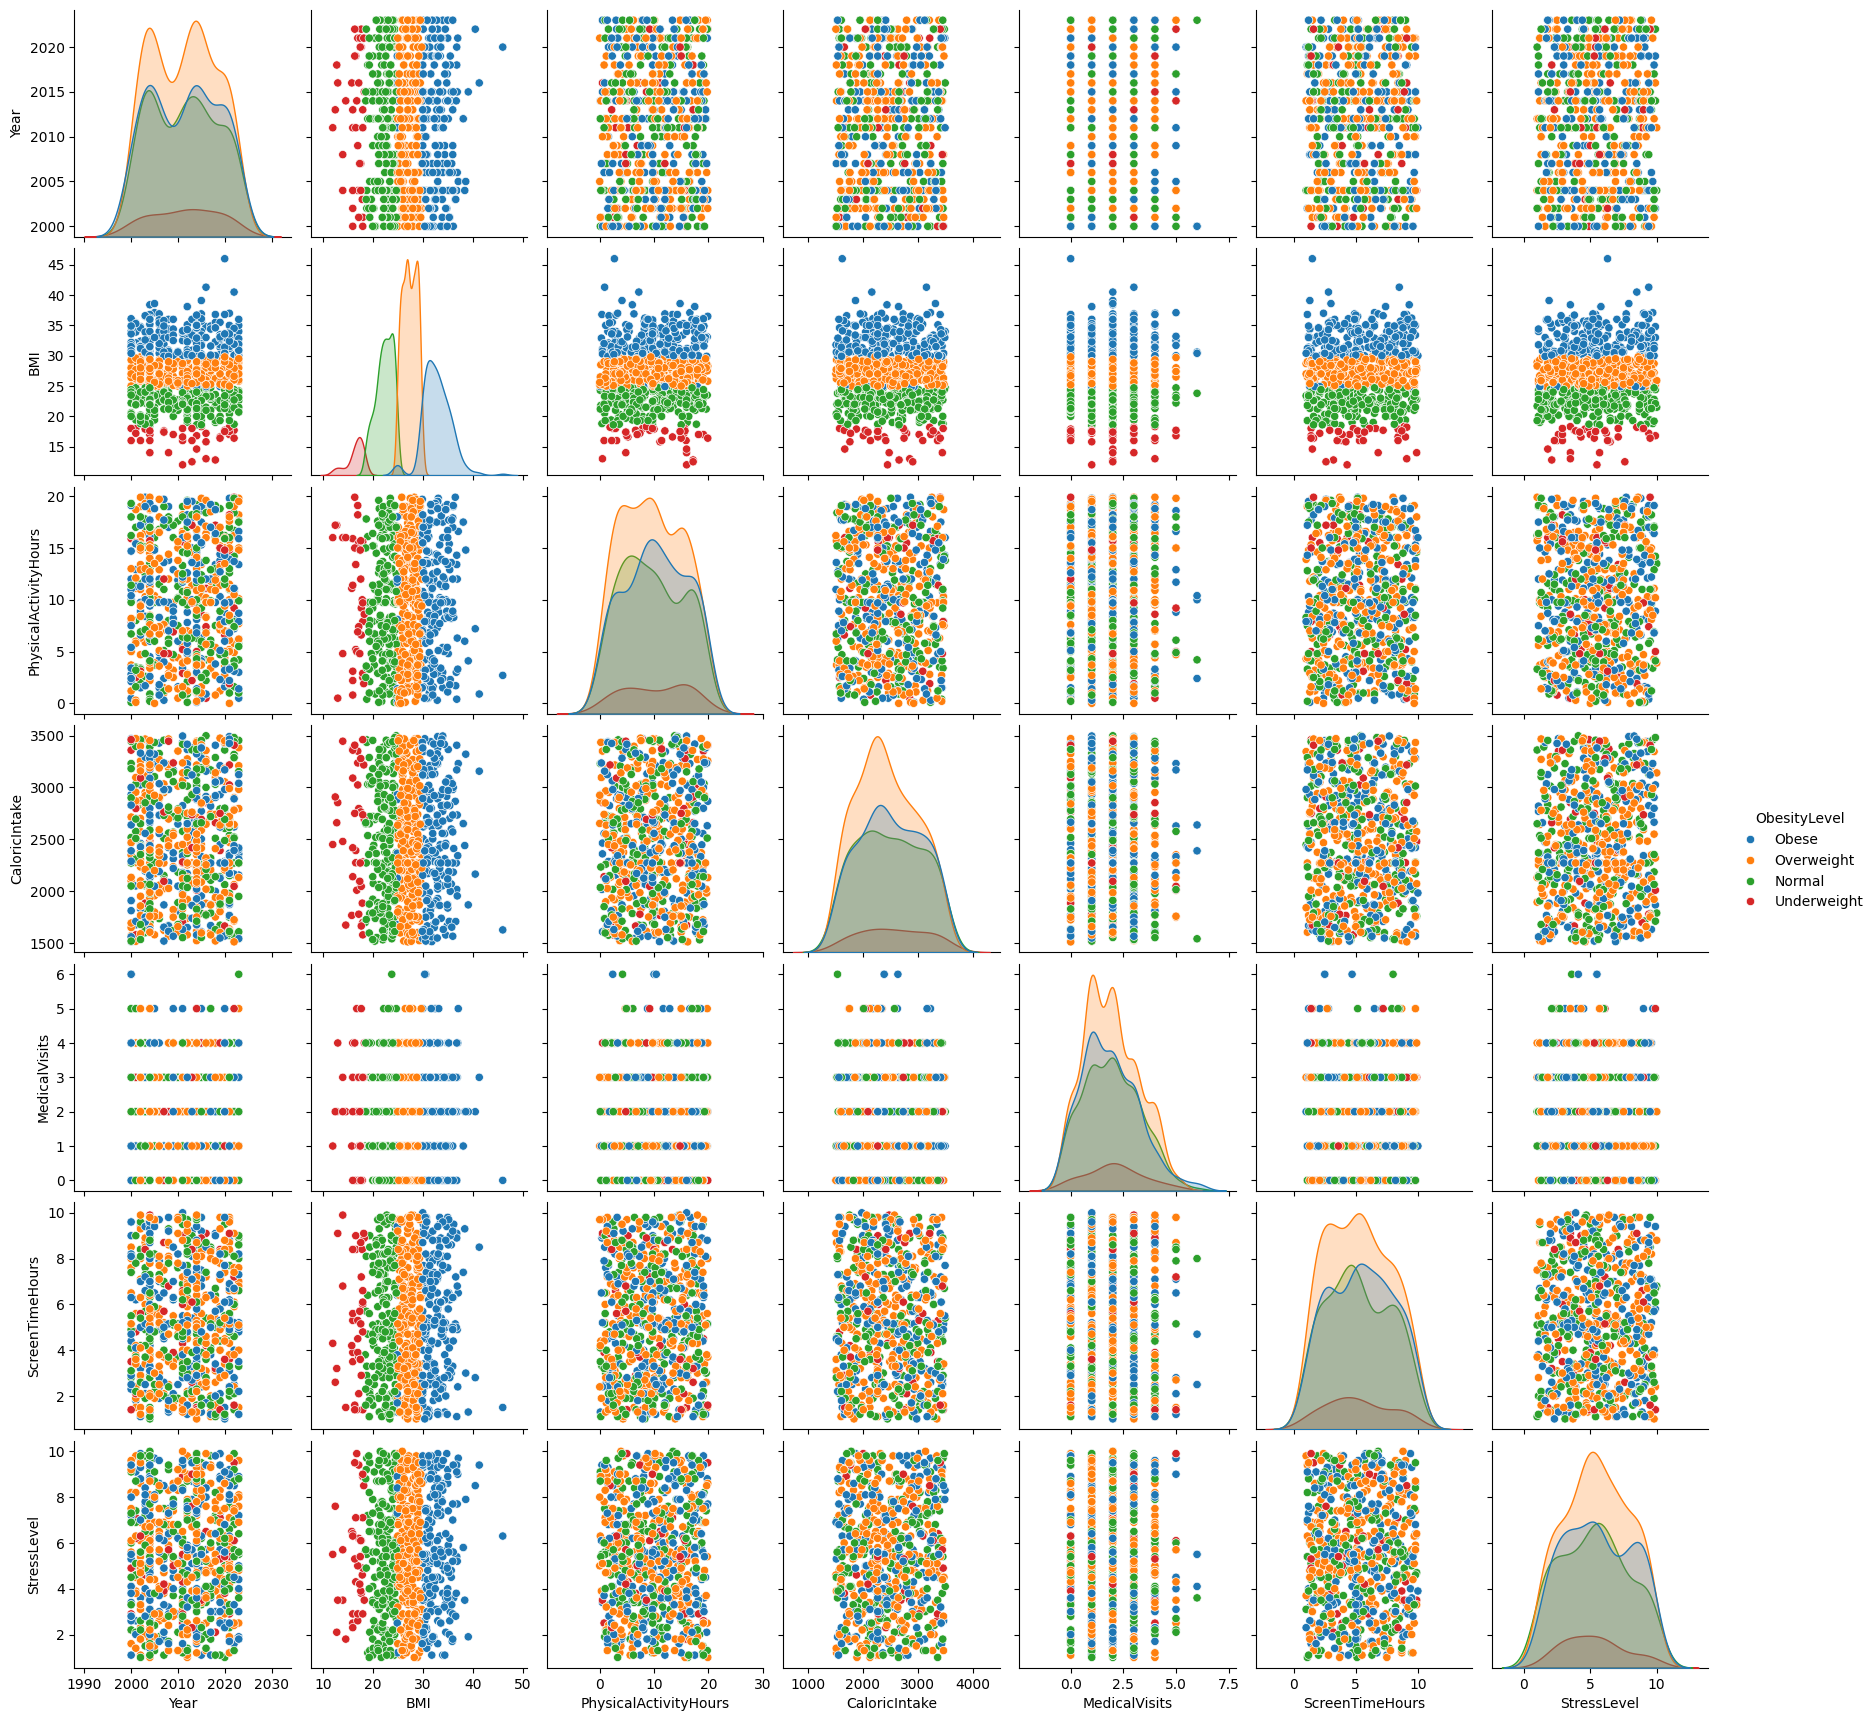

In [62]:
# To have a general look over dataset
sns.pairplot(df,hue ='ObesityLevel')

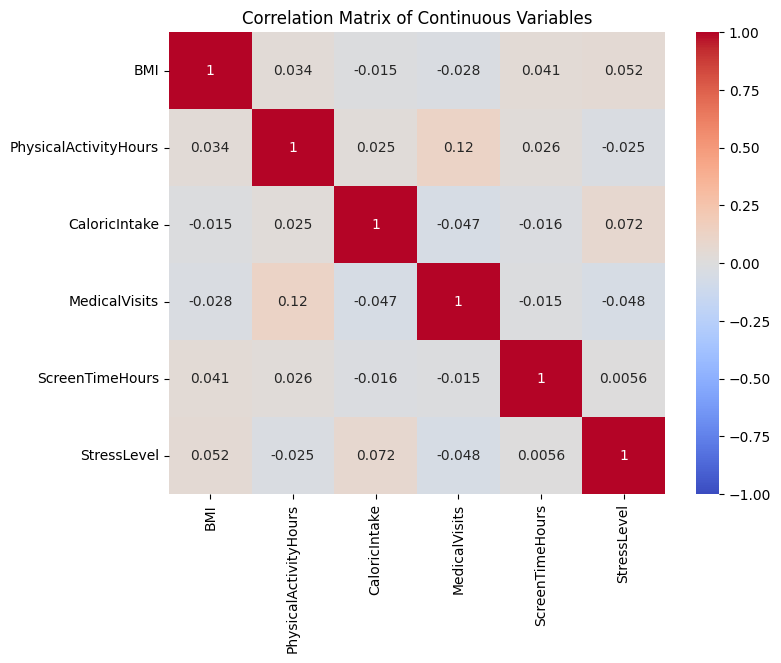

In [63]:
# HEATMAP (FROM AHMET'S PART)
df_filtered = df[(df['Gender'] != 'Unknown') & (df['IncomeLevel'] != 'Unknown') & (df['ObesityLevel'] != 'Unknown')].copy()
# Choose relevant continuous columns
continuous_cols = ['BMI', 'PhysicalActivityHours', 'CaloricIntake', 'MedicalVisits', 'ScreenTimeHours', 'StressLevel']
corr_matrix = df_filtered[continuous_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Continuous Variables')
plt.show()

## **Research Questions**

**Note:** 
- *The cleaned dataset is imported as df.*
- *Write your research questions into the research question area under your name and work under your own name.*

**Research Questions:**
- ***Ahmet:*** How does the economic status and gender affect obesity rates across?
- ***Ali:***  How does physical activity levels affect calorie intake across different obesity levels?
- ***Boran:*** How does the amount of screen time affect stress levels, and does this relationship vary across different states?
- ***İlker:*** What is the effect of factors such as gender, age and physical activity level on the obesity rate among adults of different income levels in the United States? In which age group and gender are these interactions more pronounced?
- ***Kadir:*** How does the BMI levels change accross years and does it have any trends?
- ***Mehmet:*** Does the amount of medical visitations change depending on the BMI/obesity/caloric intake factors? Is there a positive or negative relationship? 
- ***Talha:*** How does physical activity mediate the relationship between screen time and caloric intake for different genders?

### **Ahmet's Question:**

***Research Question:*** How does the economic status and gender affect obesity rates across?

In [64]:
# View data structure
df.info()

# Check summary for numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   735 non-null    int64  
 1   State                  735 non-null    object 
 2   AgeGroup               735 non-null    object 
 3   IncomeLevel            735 non-null    object 
 4   Gender                 735 non-null    object 
 5   DietType               735 non-null    object 
 6   ActivityLevel          735 non-null    object 
 7   ObesityLevel           735 non-null    object 
 8   BMI                    735 non-null    float64
 9   PhysicalActivityHours  735 non-null    float64
 10  CaloricIntake          735 non-null    float64
 11  MedicalVisits          735 non-null    int64  
 12  ScreenTimeHours        735 non-null    float64
 13  StressLevel            735 non-null    float64
dtypes: float64(5), int64(2), object(7)
memory usage: 80.5+ KB


,Year,BMI,PhysicalActivityHours,CaloricIntake,MedicalVisits,ScreenTimeHours,StressLevel
count,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000
mean,2011.288435,26.992789,9.866871,2478.428027,1.914286,5.290544,5.453061
std,6.982154,5.066007,5.630471,560.640914,1.303736,2.521937,2.475832
min,2000.000000,12.000000,0.000000,1512.400000,0.000000,1.000000,1.000000
25%,2004.000000,23.700000,5.000000,2047.650000,1.000000,3.100000,3.400000
50%,2012.000000,27.000000,9.750000,2437.100000,2.000000,5.150000,5.400000
75%,2017.000000,30.250000,14.950000,2937.250000,3.000000,7.400000,7.400000
max,2023.000000,46.000000,19.900000,3497.600000,6.000000,10.000000,10.000000


In [65]:
#Frequency Tables & Summary Statistics Since gender income level obesity level bmi values are important for my question, I examined their values and summary statistics.

In [66]:
#Among these, only bmi cont others are categorical. As seen for BMI, mean is 26 standard deviation is 5. Even if we accept 3 standard deviation above the mean as outlier, the maximum and minimum value is more than this. Therefore, we can see that there is an outlier in the data. Therefore, we can say that the whisker plot is suitable.

In [67]:
# Unique categories in Gender, IncomeLevel, ObesityLevel
print("Gender categories:\n", df['Gender'].value_counts(), "\n")
print("IncomeLevel categories:\n", df['IncomeLevel'].value_counts(), "\n")
print("ObesityLevel categories:\n", df['ObesityLevel'].value_counts(), "\n")

# Summary stats for BMI
print("BMI statistics:\n", df['BMI'].describe(), "\n")

Gender categories:
 Gender
Female     379
Male       337
Unknown     19
Name: count, dtype: int64 

IncomeLevel categories:
 IncomeLevel
Middle     259
Low        240
High       217
Unknown     19
Name: count, dtype: int64 

ObesityLevel categories:
 ObesityLevel
Overweight     281
Obese          216
Normal         199
Underweight     39
Name: count, dtype: int64 

BMI statistics:
 count    735.000000
mean      26.992789
std        5.066007
min       12.000000
25%       23.700000
50%       27.000000
75%       30.250000
max       46.000000
Name: BMI, dtype: float64 



In [68]:
#The "unkown" instances do not provide any insight to our research question. That is, the unkown gender's unkown income level and unkown obesity level do not provide any information. Therefore, I will remove them from the dataset.

In [69]:
# Filter out unknown values for visualization
df_filtered = df[(df['Gender'] != 'Unknown') & (df['IncomeLevel'] != 'Unknown') & (df['ObesityLevel'] != 'Unknown')].copy()

In [70]:
# We can use heatmap to examine the correlation of related features. When we look at the heatmap, we cannot say that any feature is directly correlated with each other. This is not enough to find an answer to a single feature search question. For this reason, we will examine multivariate graphs.

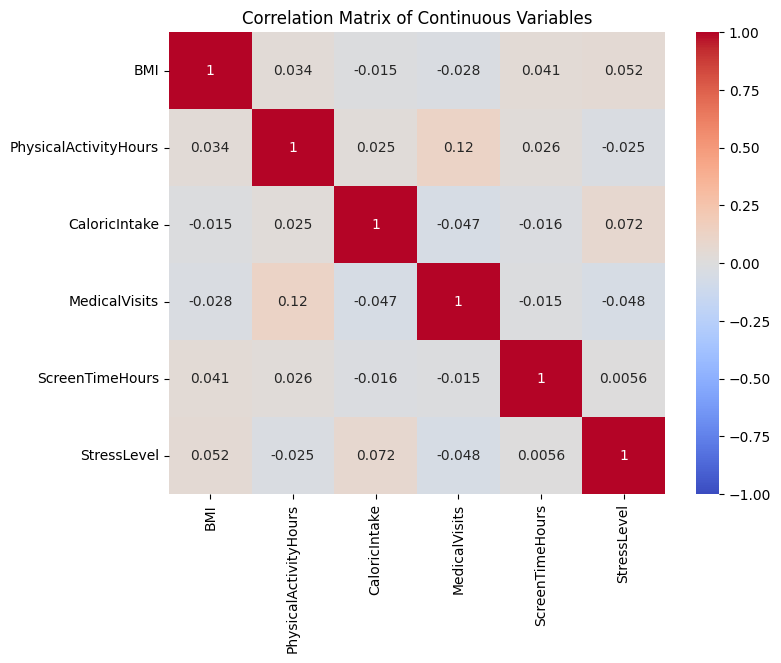

In [71]:
# HEATMAP
# Choose relevant continuous columns
continuous_cols = ['BMI', 'PhysicalActivityHours', 'CaloricIntake', 'MedicalVisits', 'ScreenTimeHours', 'StressLevel']
corr_matrix = df_filtered[continuous_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Continuous Variables')
plt.show()

In [72]:
#This map suggests multiple features combined may explain obesity better than any single feature alone. Obesity is influenced by a combination of diet, activity, income, gender, stress, etc., rather than a simple one-to-one relationship.

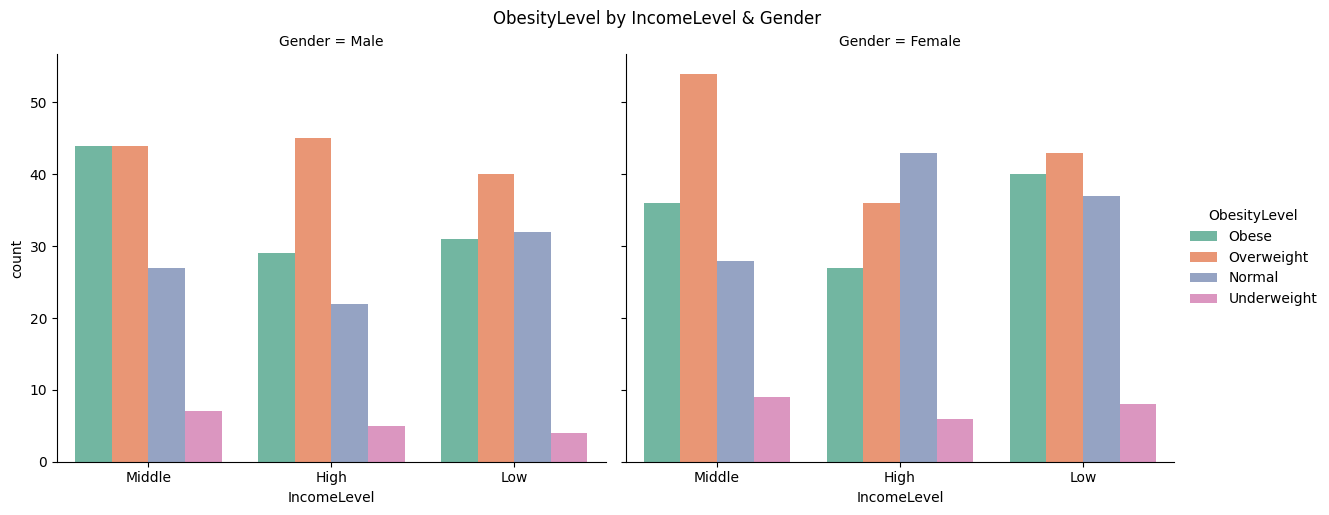

In [73]:
# Interaction: IncomeLevel, Gender, and ObesityLevel
g = sns.catplot(
    data=df_filtered, 
    x='IncomeLevel', 
    hue='ObesityLevel', 
    col='Gender', 
    kind='count',
    palette='Set2',
    height=5, aspect=1.2
)
g.fig.suptitle('ObesityLevel by IncomeLevel & Gender', y=1.02)
plt.show()

In [74]:
#We had both obese and overweight categories in the dataset. I combined them into a single category called "Extra Weight" to simplify the analysis

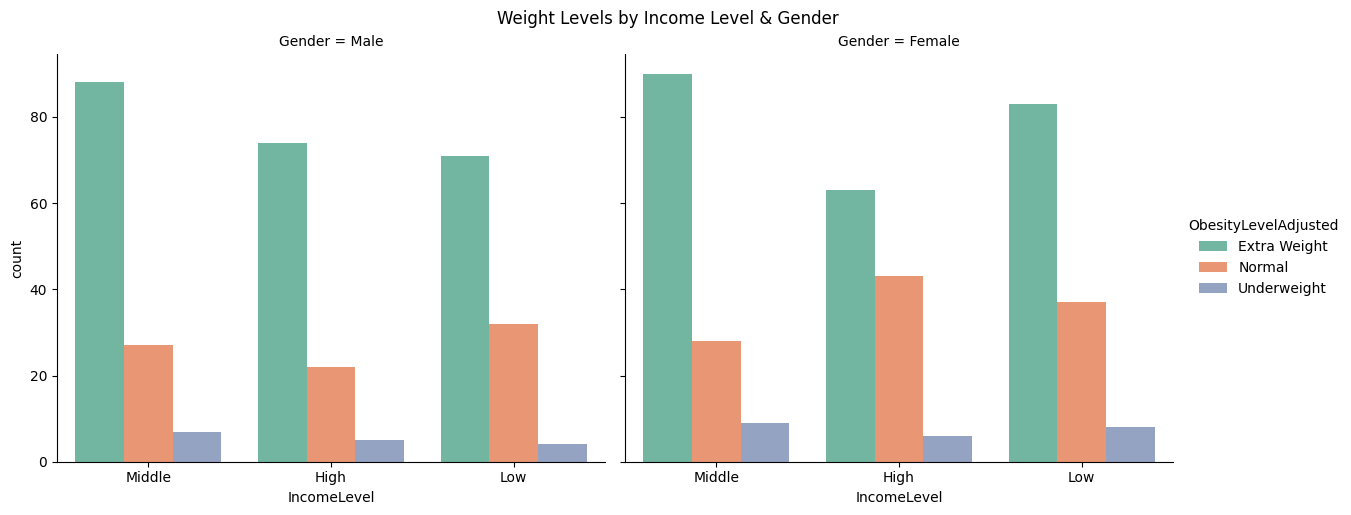

In [75]:
df_filtered['ObesityLevelAdjusted'] = df_filtered['ObesityLevel'].replace(['Overweight', 'Obese'], 'Extra Weight')

g = sns.catplot(
    data=df_filtered, 
    x='IncomeLevel', 
    hue='ObesityLevelAdjusted', 
    col='Gender', 
    kind='count',
    palette='Set2',
    height=5, aspect=1.2
)
g.fig.suptitle('Weight Levels by Income Level & Gender', y=1.02)
plt.show()

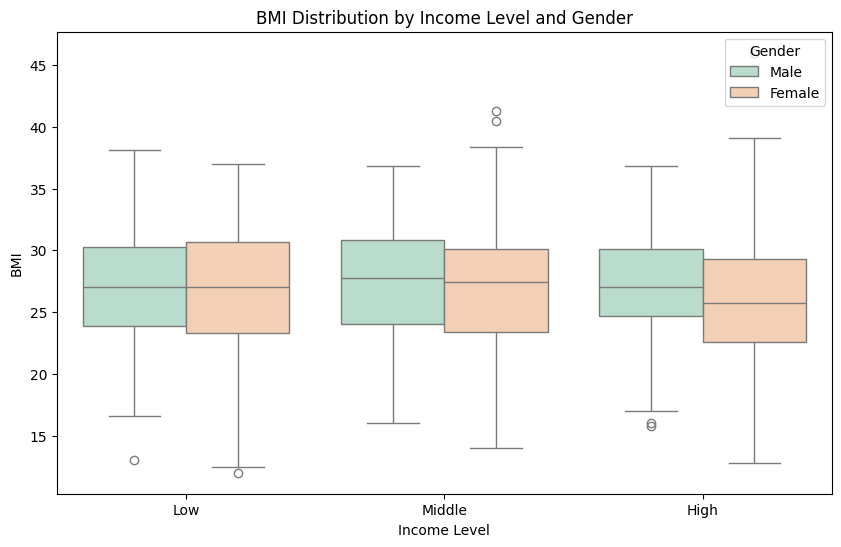

In [76]:
# BMI Distribution by IncomeLevel and Gender with specific order
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_filtered,
    x='IncomeLevel',
    y='BMI',
    hue='Gender',
    order=['Low', 'Middle', 'High'],  # Ordering the IncomeLevel
    palette='Pastel2'
)
plt.title('BMI Distribution by Income Level and Gender')
plt.xlabel('Income Level')
plt.ylabel('BMI')
plt.legend(title='Gender', loc='upper right')
plt.show()

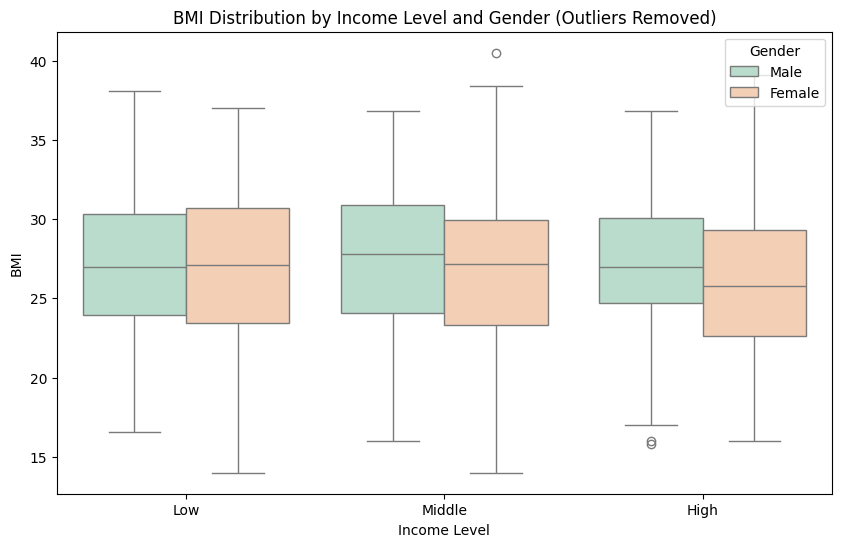

In [77]:
# Calculate the IQR for BMI with stricter outlier removal
Q1 = df_filtered['BMI'].quantile(0.25)
Q3 = df_filtered['BMI'].quantile(0.75)
IQR = Q3 - Q1

# Define stricter outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers more strictly
df_filtered_no_outliers = df_filtered[(df_filtered['BMI'] >= lower_bound) & (df_filtered['BMI'] <= upper_bound)]

# Plotting the boxplot without outliers
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_filtered_no_outliers,
    x='IncomeLevel',
    y='BMI',
    hue='Gender',
    order=['Low', 'Middle', 'High'],  # Ordering the IncomeLevel
    palette='Pastel2'
)
plt.title('BMI Distribution by Income Level and Gender (Outliers Removed)')
plt.xlabel('Income Level')
plt.ylabel('BMI')
plt.legend(title='Gender', loc='upper right')
plt.show()

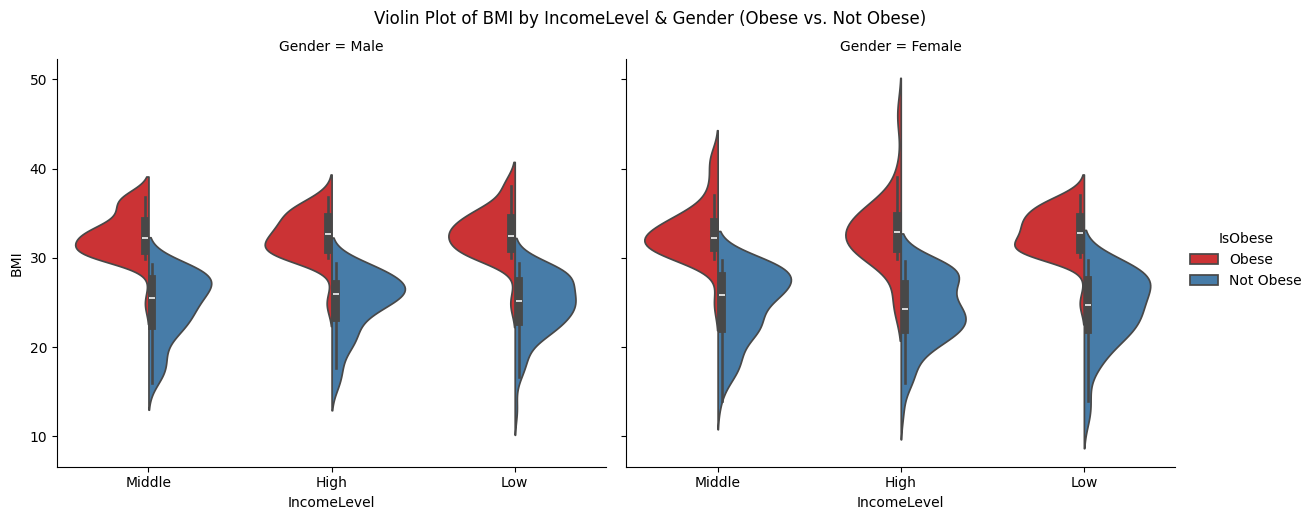

In [78]:
import numpy as np

# Create a binary column if you only want 'Obese' vs 'Non-Obese' 
# (this is optional; you can keep all categories if you'd prefer)
df_filtered['IsObese'] = np.where(df_filtered['ObesityLevel'] == 'Obese', 'Obese', 'Not Obese')

g = sns.catplot(
    data=df_filtered, 
    x='IncomeLevel', 
    y='BMI',
    hue='IsObese',           # or hue='Gender' / 'ObesityLevel'
    col='Gender', 
    kind='violin',
    split=True,  # shows both distributions side by side in one violin
    height=5, aspect=1.2,
    palette='Set1'
)
g.fig.suptitle('Violin Plot of BMI by IncomeLevel & Gender (Obese vs. Not Obese)', y=1.03)
plt.show()

### **Ali's Question:**

***Research Question:*** How does physical activity levels affect calorie intake across different obesity levels?

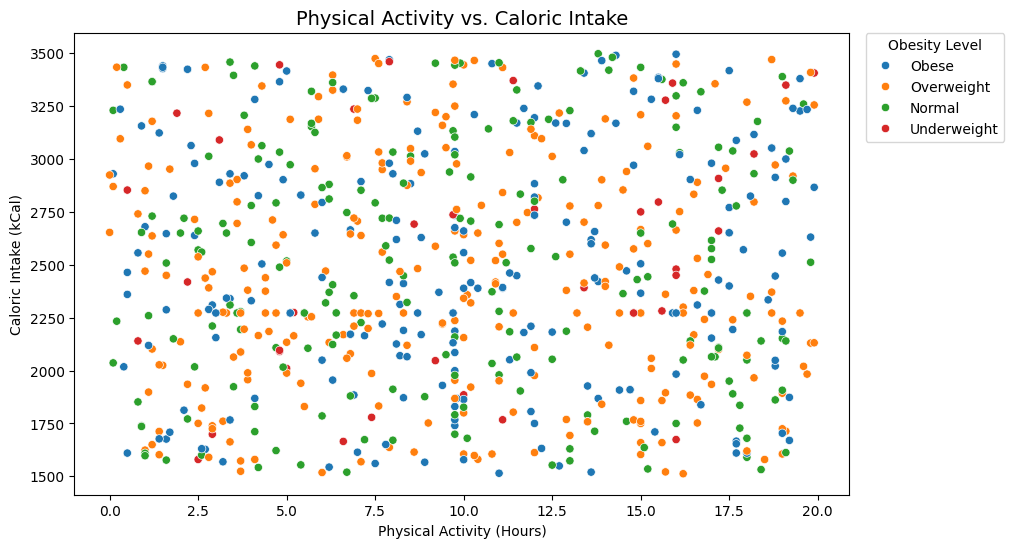

In [79]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data = df, x = 'PhysicalActivityHours', y = 'CaloricIntake', hue = 'ObesityLevel')
plt.title('Physical Activity vs. Caloric Intake', fontsize=14)
plt.xlabel('Physical Activity (Hours)')
plt.ylabel('Caloric Intake (kCal)')
plt.legend(title='Obesity Level', bbox_to_anchor=(1.2, 1), loc='upper right', borderaxespad=0)
plt.show()

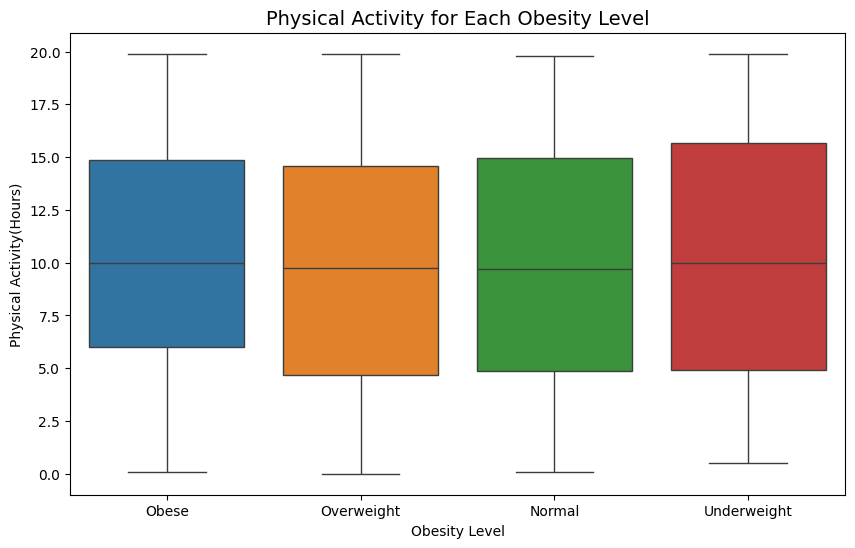

In [80]:
plt.figure(figsize=(10, 6))
sns.boxplot(data = df, x = 'ObesityLevel', y = 'PhysicalActivityHours', hue = 'ObesityLevel')
plt.title('Physical Activity for Each Obesity Level', fontsize = 14)
plt.xlabel('Obesity Level')
plt.ylabel('Physical Activity(Hours)')
plt.show()

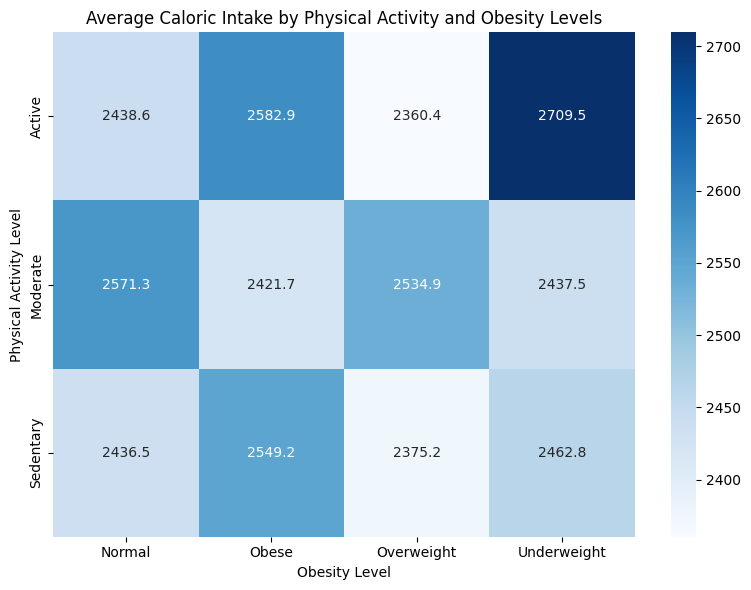

In [81]:
heatmap_data = df.groupby(['ActivityLevel', 'ObesityLevel'])['CaloricIntake'].mean().unstack()
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True,cmap = 'Blues', fmt='.1f')
plt.title('Average Caloric Intake by Physical Activity and Obesity Levels')
plt.xlabel('Obesity Level')
plt.ylabel('Physical Activity Level')
plt.tight_layout()
plt.show()

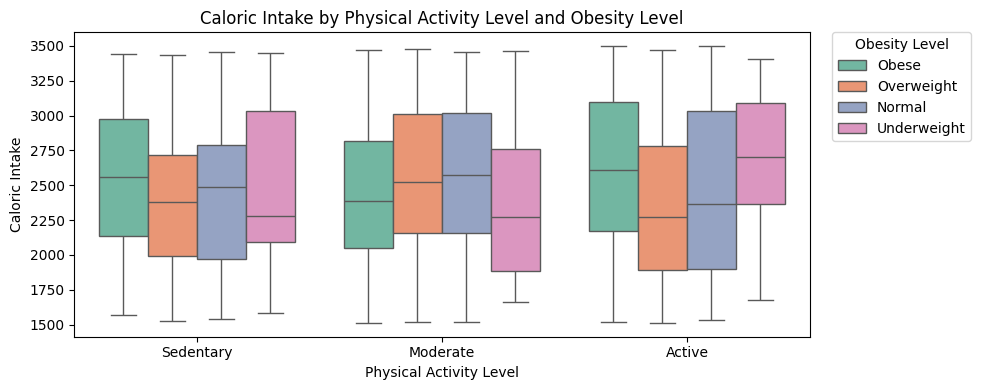

In [82]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='ActivityLevel', y='CaloricIntake', hue='ObesityLevel', palette='Set2')
plt.title('Caloric Intake by Physical Activity Level and Obesity Level')
plt.xlabel('Physical Activity Level')
plt.ylabel('Caloric Intake')
plt.legend(title = 'Obesity Level',bbox_to_anchor=(1.22, 1), loc='upper right', borderaxespad=0)
plt.tight_layout()
plt.show()

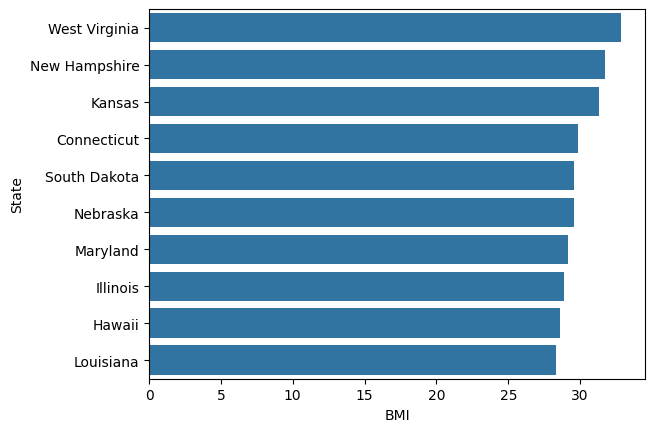

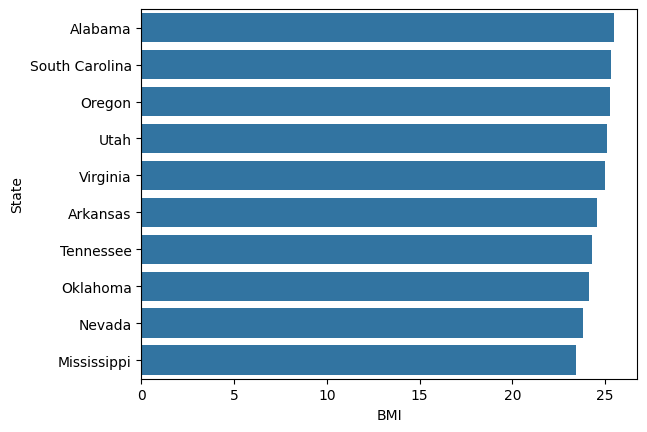

In [83]:
df_filtered = df[df['State'] != 'Unknown']

state_bmi_avg_highest = df_filtered.groupby('State')['BMI'].mean().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data = state_bmi_avg_highest, x = 'BMI', y = 'State')
plt.show()

state_bmi_avg_lowest = df_filtered.groupby('State')['BMI'].mean().sort_values(ascending=False).tail(10).reset_index()
sns.barplot(data = state_bmi_avg_lowest, x = 'BMI', y = 'State')
plt.show()

### **Boran's Question:**

***Research Question***: How does the amount of screen time affect stress levels, and does this relationship vary across different states?

In [84]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

states = pd.read_csv('us_states.csv')
state_abbreviations = dict(zip(states['State'], states['Abbreviation']))

df['State'] = df['State'].map(state_abbreviations)


state_data = df.groupby('State')[['ScreenTimeHours', 'StressLevel']].mean().reset_index()

fig = px.choropleth(
    state_data,
    locations='State',
    locationmode='USA-states',
    color='StressLevel',
    hover_name='State',
    hover_data={'ScreenTimeHours': True, 'StressLevel': True},
    scope='usa',
    title='Stress Levels by State with Average Screen Time',
    color_continuous_scale='viridis'
)


fig.add_trace(
    go.Scattergeo(
        locationmode='USA-states',
        locations=state_data['State'],
        text=state_data['ScreenTimeHours'].round(2),
        mode='text',
        textfont=dict(size=10, color='white'),
        hoverinfo='none'
    )
)

pio.renderers.default = 'iframe'
fig.show()

/tmp/ipykernel_3755860/160343426.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




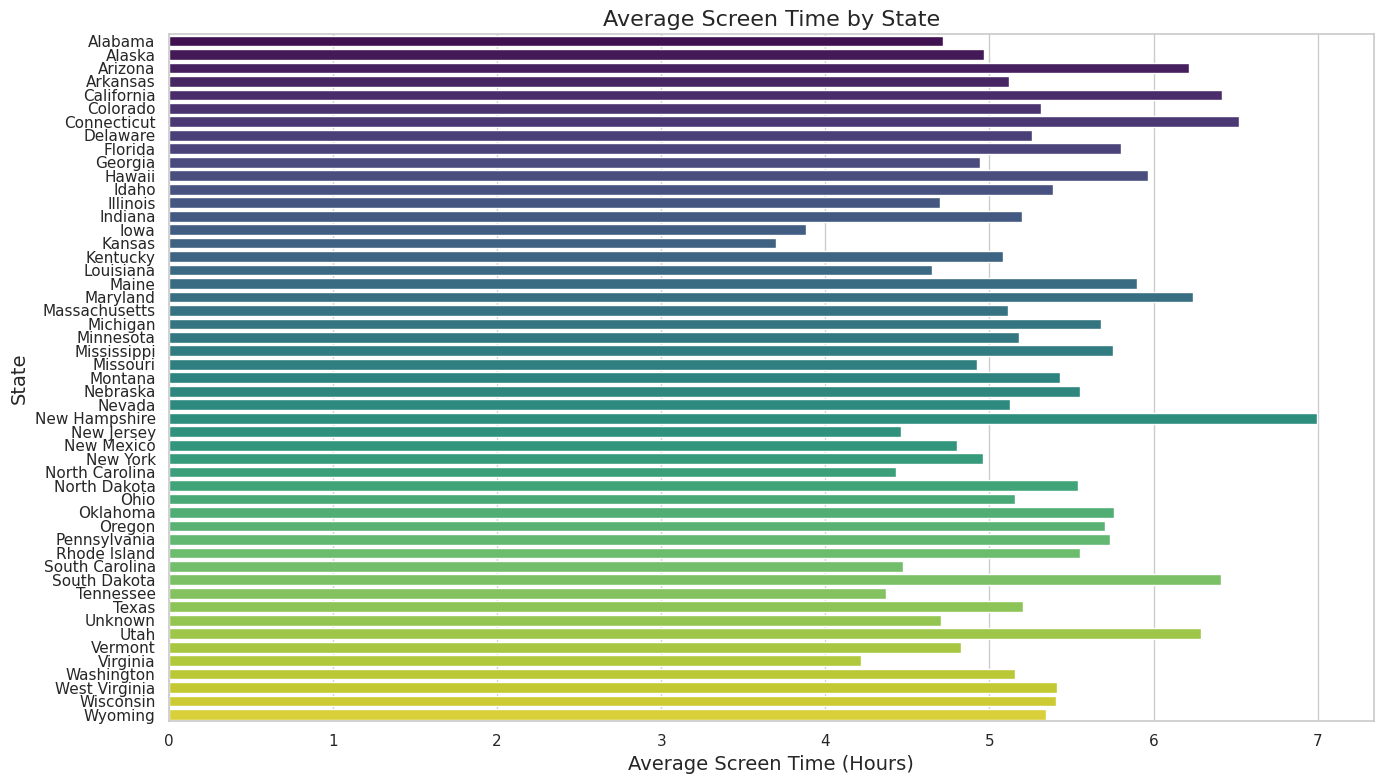

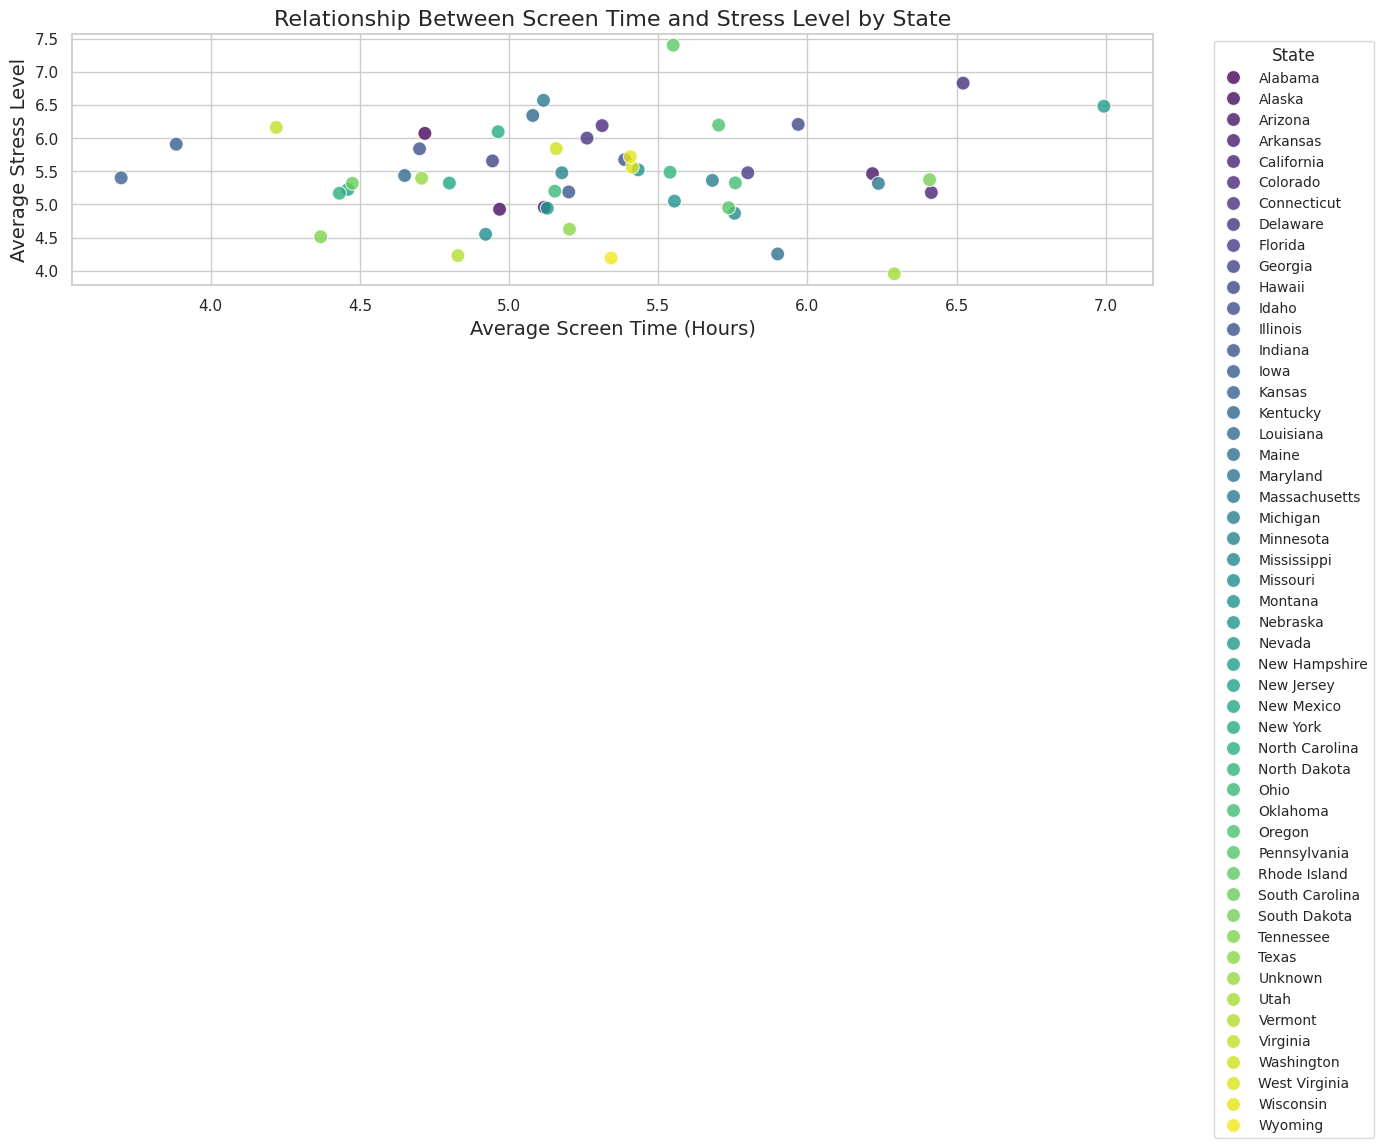

In [85]:
import pandas as pd

file_path = 'cleaned_data.csv'
data = pd.read_csv(file_path)
state_data = data.groupby('State')[['ScreenTimeHours', 'StressLevel']].mean().reset_index()
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


plt.figure(figsize=(14, 8))
sns.barplot(
    data=state_data,
    x="ScreenTimeHours",
    y="State",
    palette="viridis"
)

plt.title("Average Screen Time by State", fontsize=16)
plt.xlabel("Average Screen Time (Hours)", fontsize=14)
plt.ylabel("State", fontsize=14)
plt.tight_layout()

plt.show()
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=state_data,
    x="ScreenTimeHours",
    y="StressLevel",
    hue="State",
    palette="viridis",
    s=100,
    alpha=0.8
)


plt.title("Relationship Between Screen Time and Stress Level by State", fontsize=16)
plt.xlabel("Average Screen Time (Hours)", fontsize=14)
plt.ylabel("Average Stress Level", fontsize=14)
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
plt.tight_layout()


plt.show()



### **İlker's Question:**

***Research Question***: What is the effect of factors such as gender, age and physical activity level on the obesity rate among adults of different income levels in the United States? In which age group and gender are these interactions more pronounced?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   735 non-null    int64  
 1   State                  713 non-null    object 
 2   AgeGroup               735 non-null    object 
 3   IncomeLevel            735 non-null    object 
 4   Gender                 735 non-null    object 
 5   DietType               735 non-null    object 
 6   ActivityLevel          735 non-null    object 
 7   ObesityLevel           735 non-null    object 
 8   BMI                    735 non-null    float64
 9   PhysicalActivityHours  735 non-null    float64
 10  CaloricIntake          735 non-null    float64
 11  MedicalVisits          735 non-null    int64  
 12  ScreenTimeHours        735 non-null    float64
 13  StressLevel            735 non-null    float64
dtypes: float64(5), int64(2), object(7)
memory usage: 80.5+ KB


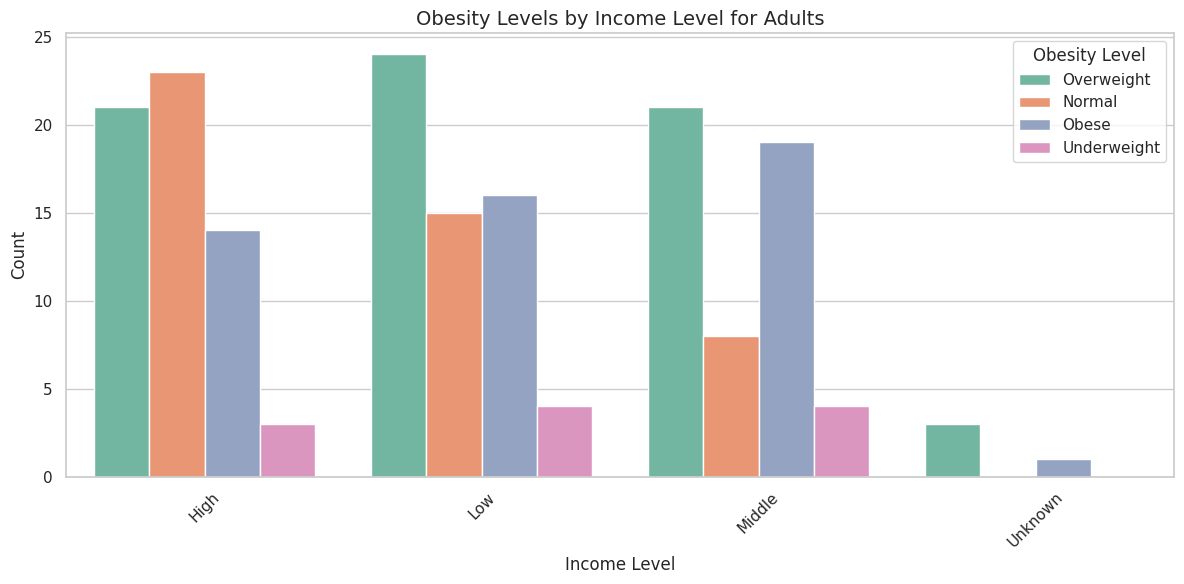

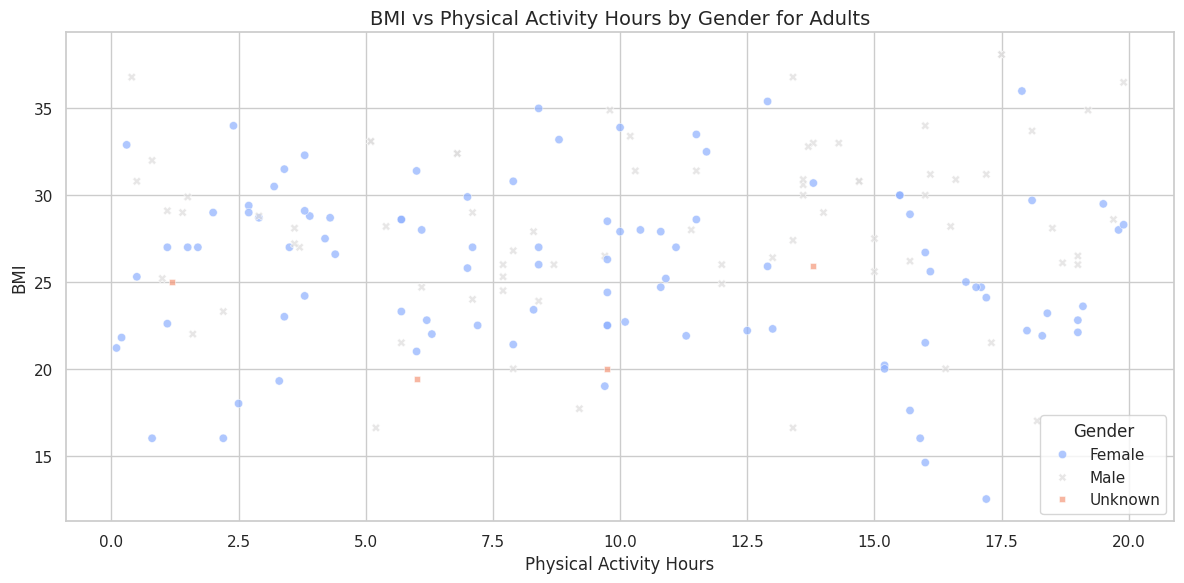

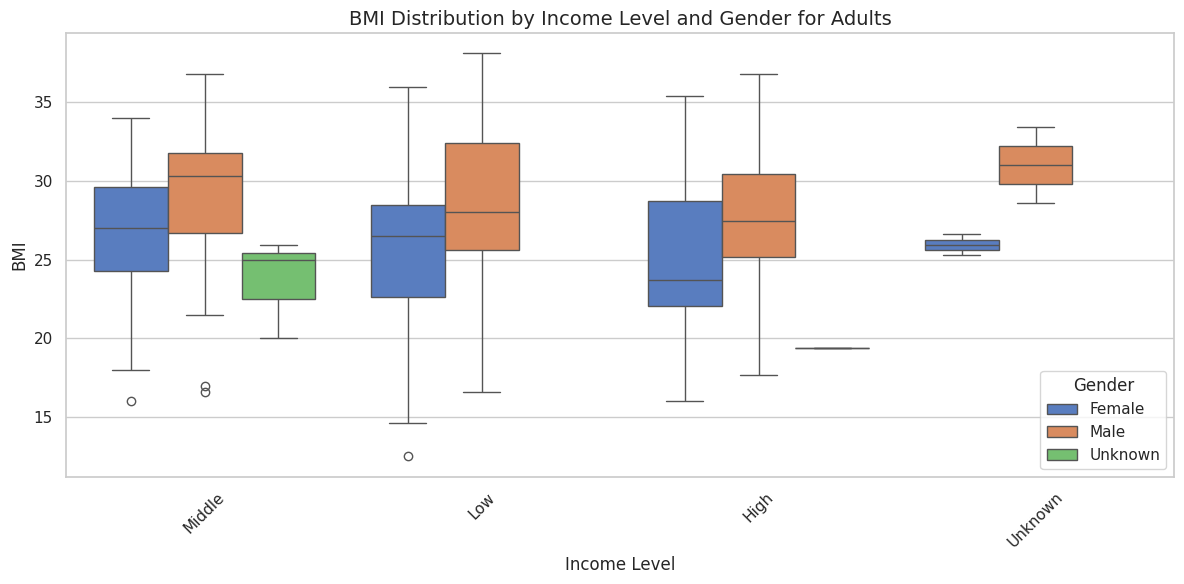

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Import the clean data as data
data= pd.read_csv('cleaned_data.csv')

df.info()
#Check summary for numerical columns
df.describe()

# Formatting of numeric columns
data["PhysicalActivityHours"] = pd.to_numeric(data["PhysicalActivityHours"], errors="coerce")
data["BMI"] = pd.to_numeric(data["BMI"], errors="coerce")

# Formatting for Adults
adult_data = data[data["AgeGroup"] == "Adults"]

# Graph 1: Obesity Distribution by Income Level and Gender
plt.figure(figsize=(12, 6))
sns.countplot(
    data=adult_data,
    x="IncomeLevel",
    hue="ObesityLevel",
    order=adult_data["IncomeLevel"].value_counts().index,
    palette="Set2"
)
plt.title("Obesity Levels by Income Level for Adults", fontsize=14)
plt.xlabel("Income Level")
plt.ylabel("Count")
plt.legend(title="Obesity Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Graph 2: BMI Distribution by Hours of Physical Activity
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=adult_data,
    x="PhysicalActivityHours",
    y="BMI",
    hue="Gender",
    style="Gender",
    palette="coolwarm",
    alpha=0.7
)
plt.title("BMI vs Physical Activity Hours by Gender for Adults", fontsize=14)
plt.xlabel("Physical Activity Hours")
plt.ylabel("BMI")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

# Chart 3: BMI Distribution by Income Level and Gender (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=adult_data,
    x="IncomeLevel",
    y="BMI",
    hue="Gender",
    palette="muted"
)
plt.title("BMI Distribution by Income Level and Gender for Adults", fontsize=14)
plt.xlabel("Income Level")
plt.ylabel("BMI")
plt.legend(title="Gender")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### **Kadir's Question:**

***Research Question:*** how does the bmi levels change accross years and does it have any trends?

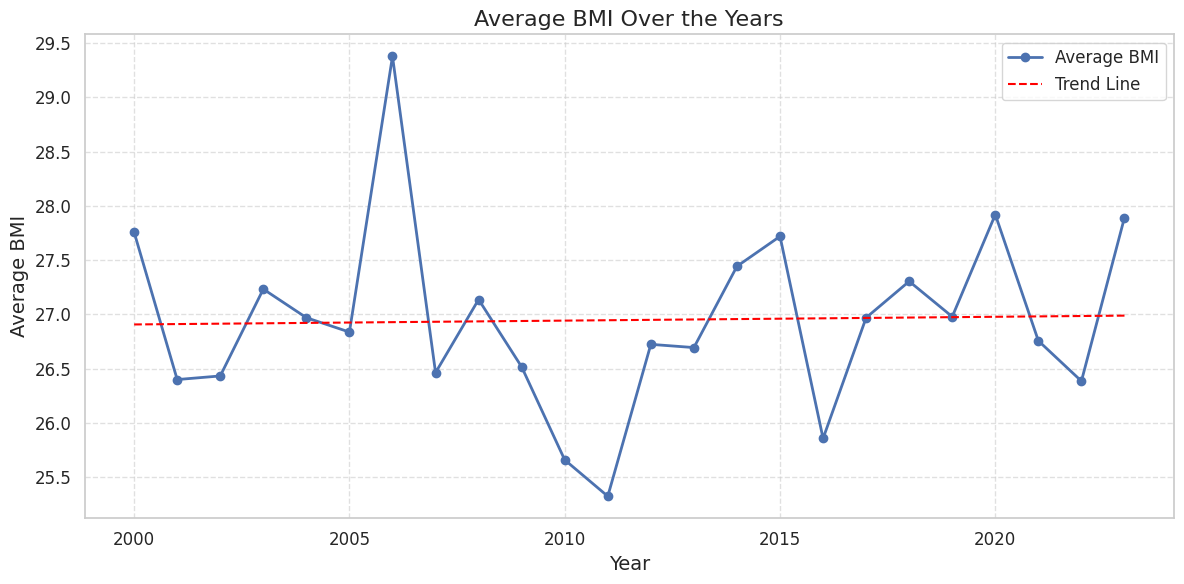

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Grouping data by year and calculate the average BMI for each year
average_bmi_by_year = df.groupby('Year')['BMI'].mean().reset_index()

# Plotting the data
plt.figure(figsize=(12, 6))
plt.plot(average_bmi_by_year['Year'], average_bmi_by_year['BMI'], marker='o', linestyle='-', linewidth=2, label='Average BMI')

# Fitting a linear trend line
z = np.polyfit(average_bmi_by_year['Year'], average_bmi_by_year['BMI'], 1)
p = np.poly1d(z)
plt.plot(average_bmi_by_year['Year'], p(average_bmi_by_year['Year']), linestyle='--', color='red', label='Trend Line')

plt.title('Average BMI Over the Years', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average BMI', fontsize=14)
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()




### **Mehmet's Question:**

***Research Question:*** Does the amount of medical visitations change for different levels of obesity depending on the BMI and/or caloric intake factors? Is there a positive or negative relationship? 

/tmp/ipykernel_3755860/3478283877.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




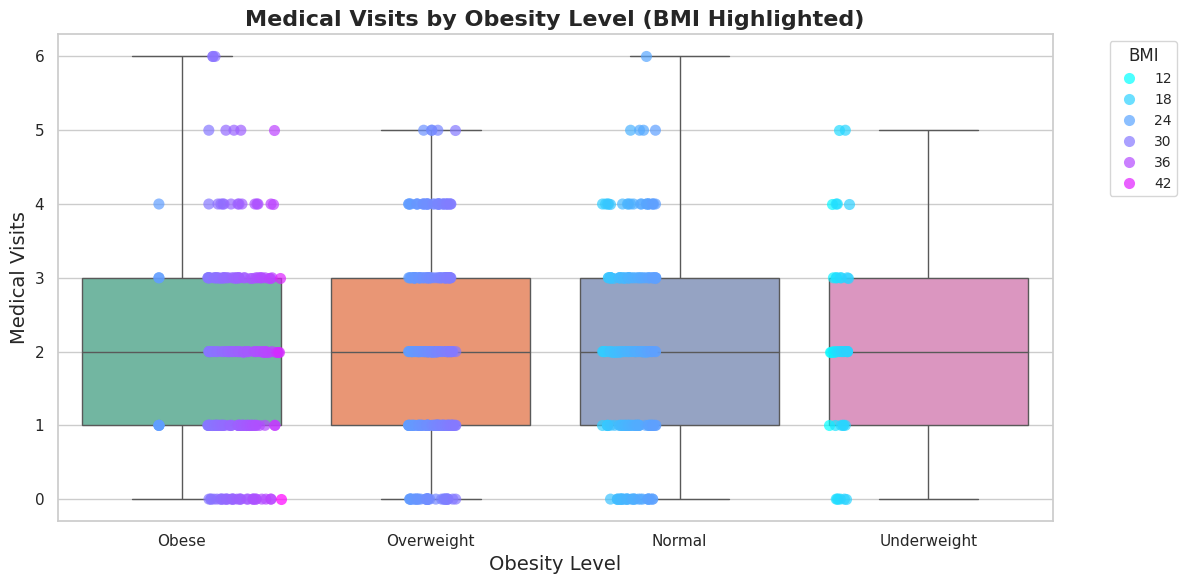

In [88]:
# Visualization 1: Medical Visits by Obesity Level with BMI as a hue factor
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="ObesityLevel", y="MedicalVisits", palette="Set2", fliersize=0)
sns.stripplot(data=df, x="ObesityLevel", y="MedicalVisits", hue="BMI", palette="cool", size=8, alpha=0.7, dodge=True)
plt.title("Medical Visits by Obesity Level (BMI Highlighted)", fontsize=16, fontweight="bold")
plt.xlabel("Obesity Level", fontsize=14)
plt.ylabel("Medical Visits", fontsize=14)
plt.legend(title="BMI", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3755860/3454021140.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




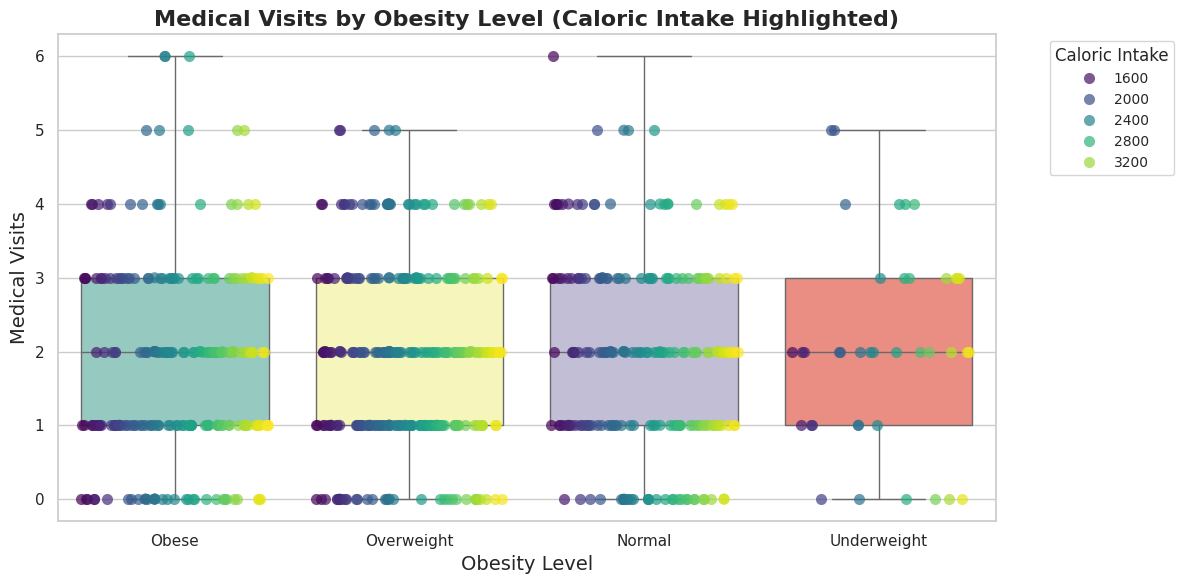

In [89]:
# Visualization 2: Medical Visits by Obesity Level with Caloric Intake as a hue factor
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="ObesityLevel", y="MedicalVisits", palette="Set3", fliersize=0)
sns.stripplot(data=df, x="ObesityLevel", y="MedicalVisits", hue="CaloricIntake", palette="viridis", size=8, alpha=0.7, dodge=True)
plt.title("Medical Visits by Obesity Level (Caloric Intake Highlighted)", fontsize=16, fontweight="bold")
plt.xlabel("Obesity Level", fontsize=14)
plt.ylabel("Medical Visits", fontsize=14)
plt.legend(title="Caloric Intake", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3755860/4006484269.py:6: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



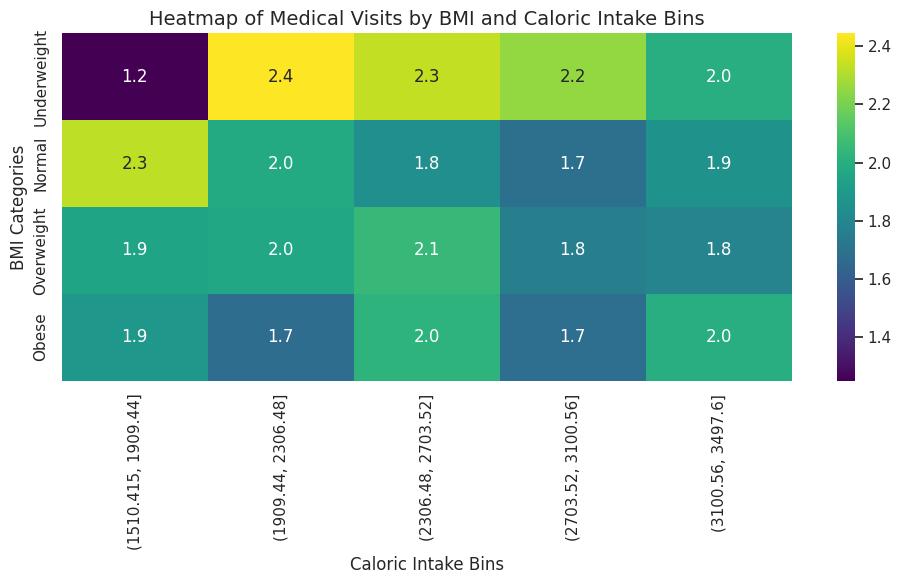

In [92]:
# Create BMI and Caloric Intake bins
df['BMI_Bin'] = pd.cut(df['BMI'], bins=[0, 18.5, 24.9, 29.9, 40], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df['Caloric_Bin'] = pd.cut(df['CaloricIntake'], bins=5)

# Create a pivot table for the heatmap
heatmap_data = df.pivot_table(values='MedicalVisits', index='BMI_Bin', columns='Caloric_Bin', aggfunc='mean')

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.1f')
plt.title('Heatmap of Medical Visits by BMI and Caloric Intake Bins', fontsize=14)
plt.xlabel('Caloric Intake Bins')
plt.ylabel('BMI Categories')
plt.tight_layout()
plt.show()


/tmp/ipykernel_3755860/30003415.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



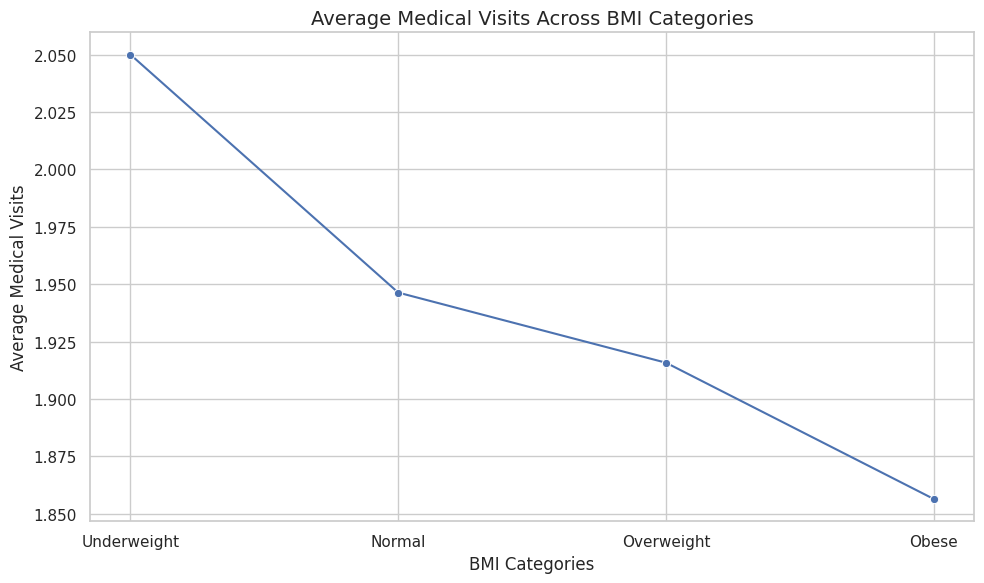

In [93]:
# Group by BMI_Bin and calculate mean medical visits
line_data = df.groupby('BMI_Bin')['MedicalVisits'].mean().reset_index()

# Plot the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=line_data, x='BMI_Bin', y='MedicalVisits', marker='o')
plt.title('Average Medical Visits Across BMI Categories', fontsize=14)
plt.xlabel('BMI Categories')
plt.ylabel('Average Medical Visits')
plt.tight_layout()
plt.show()


### **Talha's Question:**

***Research Question:*** How does physical activity mediate the relationship between screen time and for different genders?

In [98]:
palette = "husl"


gender = "Gender"
screen_time = "ScreenTimeHours"
activity_level = "ActivityLevel"
physical_activity= "PhysicalActivityHours"

gender_label = "Gender"
screen_time_label = "Screen Time"
activity_level_label = "Activity Level"
physical_activity_label = "Physical Activity"

# Filter out unknown values for visualization
df_filtered = df[(df['Gender'] != 'Unknown') & (df['ScreenTimeHours'] != 'Unknown') & (df['ActivityLevel'] != 'Unknown') ].copy()


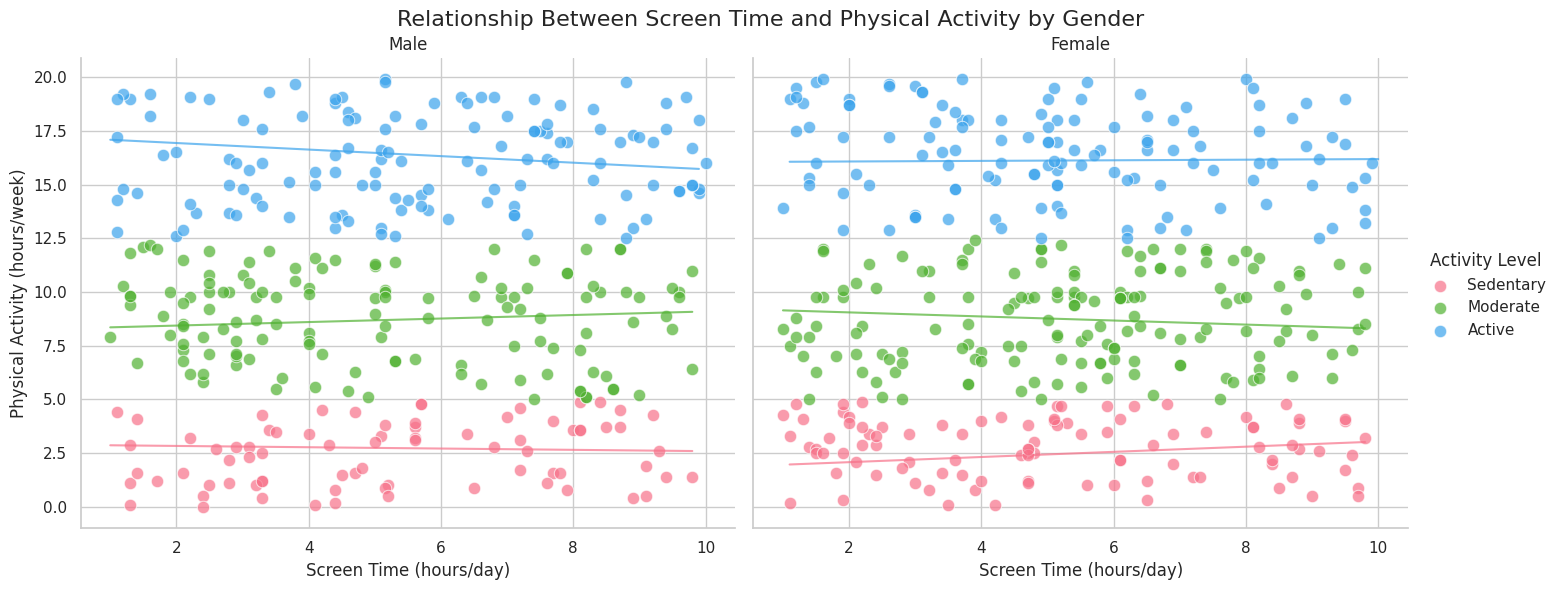

In [99]:
g = sns.FacetGrid(
    data=df_filtered,
    col=gender,
    hue=activity_level,
    palette=palette,
    height=6,
    aspect=1.2,
)

g.map(
    sns.scatterplot,
    screen_time,
    physical_activity,
    alpha=0.7,
    s=80,
)
hue_colors = g._legend_data
for i, (gender_value, subdata) in zip(g.axes.flatten(), df_filtered.groupby(gender)):
    for level in subdata[activity_level].unique():
        color = hue_colors[level].get_facecolor()

        sns.regplot(
            data=subdata[subdata[activity_level] == level],
            x=screen_time,
            y=physical_activity,
            scatter=False,
            ax=i,
            line_kws={"linestyle": "-", "linewidth": 1.5,"color":color},
            ci=None,
        )


g.set_titles("{col_name}")  # Use column names Male|Female as titles
g.set_axis_labels(
    f"{screen_time_label} (hours/day)", f"{physical_activity_label} (hours/week)"
)

g.add_legend(title=f"{activity_level_label}")

plt.subplots_adjust(top=0.9)
g.fig.suptitle(
    f"Relationship Between {screen_time_label} and {physical_activity_label} by {gender_label}",
    fontsize=16,
)
plt.show()

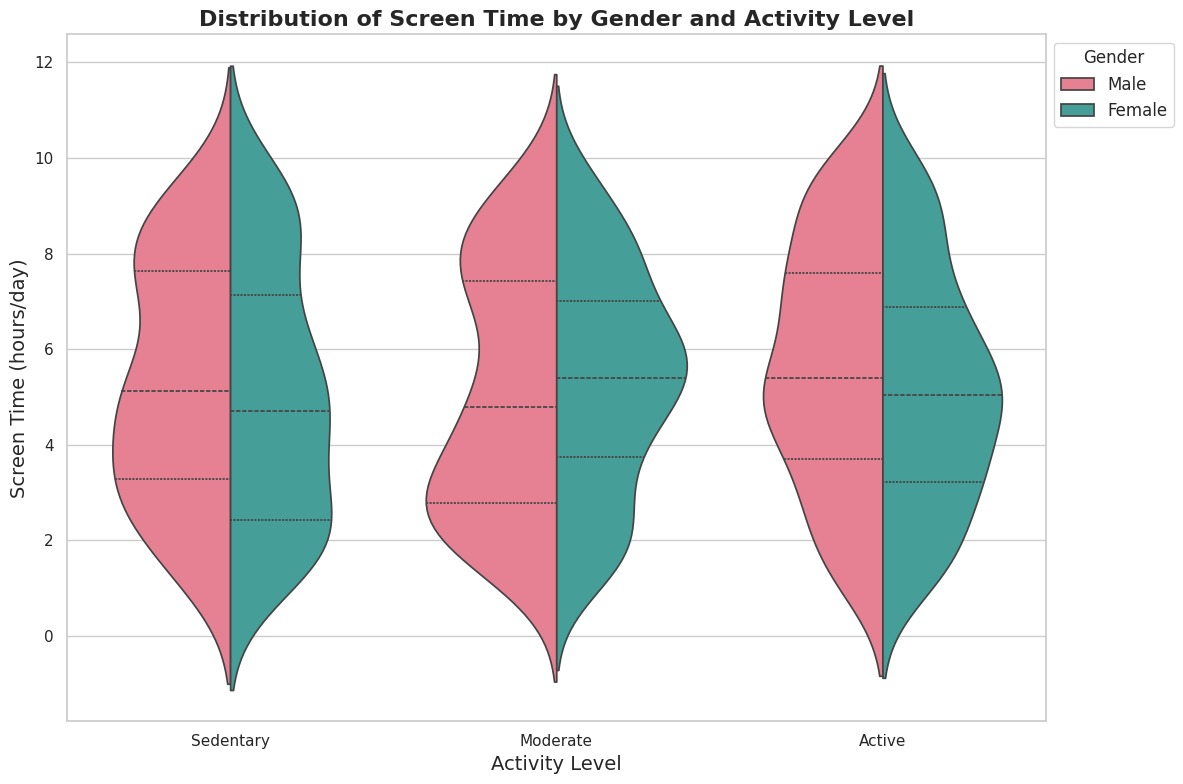

In [100]:
plt.figure(figsize=(12, 8))
sns.violinplot(
    data=df_filtered,
    x=activity_level,
    y=screen_time,
    hue=gender,
    split=True,
    inner='quartile',
    palette=palette
)

plt.title(f'Distribution of {screen_time_label} by {gender_label} and {activity_level_label}', fontsize=16, fontweight='bold')
plt.xlabel(activity_level_label, fontsize=14)
plt.ylabel(f'{screen_time_label} (hours/day)', fontsize=14)

plt.legend(title=f"{gender_label}", loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)

plt.tight_layout()
plt.show()
